In [15]:
import re
import base64
import io
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
DOWNSAMPLE_RATE = 3   # Plot every Nth frame (to reduce lag)
MAX_FRAMES = 500      # Limit total frames for smoother testing (set to None for full file)

def parse_xml_config(filepath):
    """Extracts Scale, Offsets, and Base64 Background Image"""
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        
        # 1. Background Image (Base64)
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            
            # Get Image Dimensions for Plotly Layout
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass

        # 2. Scale & Offsets
        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))

        # 3. Sensor 0 Position (Reference for Alignment)
        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            # Convert Pixel -> Map Meters
            # Formula: (Px - BgOffset) * Scale
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
            
    return config, img_b64

def parse_evo_data(filepath):
    """Parses raw EVO data into a DataFrame"""
    data = []
    evo_s0 = {'x': 0, 'y': 0}
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    current_time = "00:00:00.000"
    
    for line in lines:
        line = line.strip()
        
        # Capture Alignment Reference (C Msg)
        if line.startswith('C;') and evo_s0['x'] == 0:
            parts = line.split(';')
            if len(parts) > 1:
                vals = parts[1].split(',')
                if len(vals) >= 3:
                    evo_s0['x'] = float(vals[0])
                    evo_s0['y'] = float(vals[1])

        # Capture Time
        if ':' in line and len(line) < 15:
            current_time = line
            continue

        # Capture Tracks
        if line.startswith('F;'):
            parts = line.split(';')
            if len(parts) < 3: continue
            
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                
                try:
                    oid = int(p[0])
                    x = float(p[2])
                    y = float(p[3])
                    
                    # Heuristic: Sensor ID is often the last digit
                    sensor_id = f"Sensor {oid % 10}" 
                    
                    data.append({
                        'Time': current_time,
                        'ID': oid,
                        'X_raw': x,
                        'Y_raw': y,
                        'Sensor': sensor_id
                    })
                except: pass
                
    return pd.DataFrame(data), evo_s0

def generate_video():
    print("1. Parsing Static Map...")
    map_config, bg_image = parse_xml_config(XML_FILE)
    
    print("2. Parsing Live Data...")
    df, evo_s0 = parse_evo_data(DATA_FILE)
    
    # --- ALIGNMENT ---
    # Trans = Map_Sensor0 - Evo_Sensor0
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    
    print(f"   Alignment Vector: ({trans_x:.2f}, {trans_y:.2f})")
    
    # Apply Transform
    df['X'] = df['X_raw'] + trans_x
    df['Y'] = df['Y_raw'] + trans_y
    
    # --- DOWNSAMPLING ---
    # Get unique timestamps
    unique_times = df['Time'].unique()
    # Select every Nth timestamp
    selected_times = unique_times[::DOWNSAMPLE_RATE]
    if MAX_FRAMES:
        selected_times = selected_times[:MAX_FRAMES]
        
    # Filter DataFrame
    df_filtered = df[df['Time'].isin(selected_times)].copy()
    
    print(f"3. Generating Animation ({len(df_filtered)} points)...")
    
    # --- PLOTLY SETUP ---
    fig = px.scatter(
        df_filtered, 
        x='X', 
        y='Y', 
        animation_frame='Time', 
        animation_group='ID',
        color='Sensor',
        hover_data=['ID', 'X_raw', 'Y_raw'],
        color_discrete_map={'Sensor 0': 'cyan', 'Sensor 1': 'yellow', 'Sensor 2': 'lime', 'Sensor 3': 'magenta'},
        title="EVO Traffic Replay (Aligned)"
    )

    # Calculate Plot Extents (Map Meters)
    map_width_m = map_config['width'] * map_config['scale']
    map_height_m = map_config['height'] * map_config['scale']

    # Add Background Image
    fig.update_layout(
        images=[dict(
            source=bg_image,
            xref="x", yref="y",
            x=0, y=0,
            sizex=map_width_m, sizey=map_height_m,
            sizing="stretch",
            opacity=0.8,
            layer="below"
        )],
        xaxis=dict(range=[0, map_width_m], showgrid=False, zeroline=False),
        yaxis=dict(
            range=[map_height_m, 0], # INVERTED Y for Image Coordinates
            showgrid=False, zeroline=False
        ),
        width=1000, height=800,
        template="plotly_dark"
    )

    # Fix Animation Speed
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100 # ms per frame

    print("4. Saving to 'traffic_replay.html'...")
    fig.write_html("traffic_replay.html")
    print("Done! Open 'traffic_replay.html' in your browser.")

if __name__ == "__main__":
    generate_video()

1. Parsing Static Map...
2. Parsing Live Data...
   Alignment Vector: (172.71, 88.09)
3. Generating Animation (7844 points)...
4. Saving to 'traffic_replay.html'...
Done! Open 'traffic_replay.html' in your browser.


In [20]:
import re
import base64
import io
import math
import pandas as pd
import numpy as np
import plotly.express as px
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"

# Fusion Tuning
MATCH_RADIUS = 10.0   # Loose radius for initial candidate search
ISOLATION_DIST = 15.0 # How far other cars must be to count as "Clean Data" for calibration
MIN_OVERLAP_FRAMES = 5
DOWNSAMPLE = 2

def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass

        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content) or re.search(r'BackgroundImagePosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content) or re.search(r'BackgroundImagePosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))

        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
            
    return config, img_b64

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': None, 'y': None}
    
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('C;'):
                parts = line.split(';')
                if len(parts) > 1:
                    vals = parts[1].split(',')
                    if len(vals) >= 3:
                        evo_s0['x'] = float(vals[0])
                        evo_s0['y'] = float(vals[1])
                        break
    
    if evo_s0['x'] is None: return pd.DataFrame() 

    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']

    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    current_time = 0.0
    
    for line in lines:
        line = line.strip()
        if ':' in line and len(line) < 15:
            try:
                parts = line.split(':')
                current_time = float(parts[0])*3600 + float(parts[1])*60 + float(parts[2])
            except: pass
            continue

        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    
                    sensor_id = oid % 10
                    if sensor_id > 3: sensor_id = sensor_id % 4 

                    data.append({
                        'Time': current_time,
                        'ID': oid,
                        'X': x,
                        'Y': y,
                        'Sensor': sensor_id
                    })
                except: pass
                
    return pd.DataFrame(data)

def learn_systematic_bias(raw_tracks, s1, s2):
    """
    Looks for isolated cars to determine the average offset (bias) 
    between Sensor 1 and Sensor 2.
    """
    ids_1 = [i for s, i in raw_tracks.keys() if s == s1]
    ids_2 = [i for s, i in raw_tracks.keys() if s == s2]
    
    biases_x = []
    biases_y = []
    
    # We only check a subset to be fast
    for id1 in ids_1:
        t1 = raw_tracks[(s1, id1)]
        
        # Find frames where this car is ALONE (Sparse Data)
        # For simplicity, we just check if it has ONE match in S2 that is spatially distinct
        
        for id2 in ids_2:
            t2 = raw_tracks[(s2, id2)]
            
            # Common times
            common_times = np.intersect1d(t1['Time'].values, t2['Time'].values)
            if len(common_times) < 10: continue # Need decent overlap for stats
            
            # Align frames
            df1 = t1[t1['Time'].isin(common_times)].sort_values('Time')
            df2 = t2[t2['Time'].isin(common_times)].sort_values('Time')
            
            # Check Euclidian Dist
            dx = df1['X'].values - df2['X'].values
            dy = df1['Y'].values - df2['Y'].values
            dist = np.sqrt(dx**2 + dy**2)
            
            # If they are reasonably close (candidates) AND consistent
            if np.mean(dist) < MATCH_RADIUS:
                # This is a candidate match.
                # In a robust system, we would check if any OTHER S2 objects are close
                # to confirm isolation. For now, we assume < MATCH_RADIUS implies 
                # a match candidate.
                
                biases_x.extend(dx)
                biases_y.extend(dy)

    if not biases_x:
        return 0.0, 0.0
        
    # Robust Mean (Filter outliers)
    bx = np.array(biases_x)
    by = np.array(biases_y)
    
    # Reject anything outside 1 std dev (removes "wrong car" matches from the calibration set)
    mask = (abs(bx - np.mean(bx)) < 2 * np.std(bx)) & (abs(by - np.mean(by)) < 2 * np.std(by))
    
    final_dx = np.mean(bx[mask])
    final_dy = np.mean(by[mask])
    
    return final_dx, final_dy

def fuse_tracks_bias_aware(df):
    print("--- Running Bias-Aware Fusion Engine ---")
    
    df = df.sort_values('Time')
    
    # 1. Group Raw Tracks
    raw_tracks = {}
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        raw_tracks[(sensor, oid)] = group.drop_duplicates(subset='Time').sort_values('Time')

    matches = [] 
    sensors = sorted(df['Sensor'].unique())

    # Iterate sensor pairs
    for i in range(len(sensors)):
        for j in range(i + 1, len(sensors)):
            s1 = sensors[i]
            s2 = sensors[j]
            
            print(f"   Calibrating Pair: S{s1} vs S{s2}...")
            
            # 2. LEARN BIAS (The systematic error)
            # bias_x = S1_x - S2_x
            bias_x, bias_y = learn_systematic_bias(raw_tracks, s1, s2)
            print(f"      -> Detected Bias: S{s2} is offset by ({bias_x:.2f}, {bias_y:.2f})m relative to S{s1}")
            
            # 3. MATCH WITH BIAS CORRECTION
            ids_1 = [k for s, k in raw_tracks.keys() if s == s1]
            ids_2 = [k for s, k in raw_tracks.keys() if s == s2]
            
            for id1 in ids_1:
                t1 = raw_tracks[(s1, id1)]
                for id2 in ids_2:
                    t2 = raw_tracks[(s2, id2)]
                    
                    common_times = np.intersect1d(t1['Time'].values, t2['Time'].values)
                    if len(common_times) < MIN_OVERLAP_FRAMES: continue
                    
                    df1_c = t1[t1['Time'].isin(common_times)].sort_values('Time')
                    df2_c = t2[t2['Time'].isin(common_times)].sort_values('Time')
                    
                    min_len = min(len(df1_c), len(df2_c))
                    df1_c = df1_c.iloc[:min_len]
                    df2_c = df2_c.iloc[:min_len]
                    
                    # BIAS CORRECTION:
                    # We shift S2 by the bias to see if it aligns with S1
                    # S2_corrected = S2 + Bias
                    # Dist = S1 - (S2 + Bias) = (S1 - S2) - Bias
                    
                    adj_dx = (df1_c['X'].values - df2_c['X'].values) - bias_x
                    adj_dy = (df1_c['Y'].values - df2_c['Y'].values) - bias_y
                    
                    dist = np.sqrt(adj_dx**2 + adj_dy**2)
                    
                    # Use a tighter threshold now that we removed bias
                    if np.mean(dist) < (MATCH_RADIUS / 2):
                        matches.append({
                            's1': s1, 'id1': id1,
                            's2': s2, 'id2': id2,
                            'times': common_times
                        })

    # 4. Generate Output (Same logic as before, just cleaner matches)
    fused_data = []
    consumed = set()
    
    for m in matches:
        s1, id1 = m['s1'], m['id1']
        s2, id2 = m['s2'], m['id2']
        times = m['times']
        
        t1 = raw_tracks[(s1, id1)]
        t2 = raw_tracks[(s2, id2)]
        
        # Direction check
        if t2['Time'].min() < t1['Time'].min():
             s1, s2 = s2, s1
             id1, id2 = id2, id1
             t1, t2 = t2, t1

        all_times = sorted(list(set(t1['Time']).union(set(t2['Time']))))
        
        # Consume inputs
        consumed.add((s1, id1))
        consumed.add((s2, id2))

        for t in all_times:
            p1 = t1[t1['Time'] == t]
            p2 = t2[t2['Time'] == t]
            
            exists1 = not p1.empty
            exists2 = not p2.empty
            
            new_x, new_y = 0, 0
            hover_txt = ""
            
            if exists1 and not exists2:
                new_x = p1['X'].values[0]
                new_y = p1['Y'].values[0]
                hover_txt = f"Fused: {id1} (S{s1} Only)"
                
            elif not exists1 and exists2:
                new_x = p2['X'].values[0]
                new_y = p2['Y'].values[0]
                hover_txt = f"Fused: {id2} (S{s2} Only)"
                
            elif exists1 and exists2:
                overlap_start = times[0]
                overlap_end = times[-1]
                duration = overlap_end - overlap_start
                alpha = 0.5
                if duration > 0: alpha = (t - overlap_start) / duration
                
                # We blend the raw positions (not bias corrected) for the visual handoff
                # because we want to visually slide from one sensor's "truth" to the other's "truth"
                x1 = p1['X'].values[0]
                y1 = p1['Y'].values[0]
                x2 = p2['X'].values[0]
                y2 = p2['Y'].values[0]
                
                new_x = (1 - alpha) * x1 + (alpha) * x2
                new_y = (1 - alpha) * y1 + (alpha) * y2
                
                hover_txt = f"Handoff {alpha*100:.0f}%: {id1} -> {id2}"

            fused_data.append({
                'Time': t,
                'X': new_x, 'Y': new_y,
                'Type': 'Fused Object',
                'Hover': hover_txt,
                'Sensor': 'Fused',
                'ColorID': id1 # Inherit color
            })
            
    fused_df = pd.DataFrame(fused_data)
    
    # Add Unmatched
    unmatched_data = []
    for (s, oid), group in raw_tracks.items():
        if (s, oid) not in consumed:
            g = group.copy()
            g['Type'] = 'Raw Sensor'
            g['Hover'] = g.apply(lambda r: f"Raw: {r['ID']} (S{r['Sensor']})", axis=1)
            g['ColorID'] = g['ID']
            g['Sensor'] = g['Sensor'] # Keep numeric for color map
            unmatched_data.append(g)
            
    if unmatched_data:
        unmatched_df = pd.concat(unmatched_data)
        return fused_df, unmatched_df
    return fused_df, pd.DataFrame()

def plot_traffic(fused_df, raw_df, map_config, bg_image):
    print("--- Generating Visualization ---")
    
    # Process Raw for background plotting
    raw_viz = raw_df.copy()
    sensor_colors = {0: 'cyan', 1: 'yellow', 2: 'lime', 3: 'magenta'}
    raw_viz['ColorVal'] = raw_viz['Sensor'].map(sensor_colors)

    if not fused_df.empty:
        fused_df['Type'] = 'Fused Object'
        fused_df['ColorVal'] = 'white'
        plot_df = pd.concat([raw_viz, fused_df])
    else:
        plot_df = raw_viz

    plot_df = plot_df.sort_values('Time')
    
    # Downsample
    times = plot_df['Time'].unique()
    sel_times = times[::DOWNSAMPLE][:500]
    plot_df = plot_df[plot_df['Time'].isin(sel_times)]
    
    fig = px.scatter(
        plot_df, 
        x='X', y='Y', 
        animation_frame='Time', 
        animation_group='Hover', 
        color='ColorVal',       
        hover_name='Hover',
        title="Bias-Corrected Sensor Fusion",
        color_discrete_map="identity"
    )
    
    fig.update_traces(marker=dict(size=12, opacity=0.8, line=dict(width=1, color='black')))
    
    # Update Background
    width_m = map_config['width'] * map_config['scale']
    height_m = map_config['height'] * map_config['scale']
    
    fig.update_layout(
        images=[dict(
            source=bg_image,
            xref="x", yref="y",
            x=0, y=0,
            sizex=width_m, sizey=height_m,
            sizing="stretch",
            opacity=0.8,
            layer="below"
        )],
        xaxis=dict(range=[0, width_m], showgrid=False, zeroline=False),
        yaxis=dict(range=[height_m, 0], showgrid=False, zeroline=False),
        template="plotly_dark",
        height=800
    )
    
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100

    print("--- Saving to 'fusion_bias_corrected.html' ---")
    fig.write_html("fusion_bias_corrected.html")
    print("Done.")

if __name__ == "__main__":
    print("1. Config...")
    cfg, img = parse_xml_config(XML_FILE)
    print("2. Aligning...")
    raw_df = parse_and_align_data(DATA_FILE, cfg)
    print("3. Fusing with Bias Learning...")
    fused_df, unmatched_df = fuse_tracks_bias_aware(raw_df)
    print("4. Plotting...")
    plot_traffic(fused_df, unmatched_df, cfg, img)

1. Config...
2. Aligning...
3. Fusing with Bias Learning...
--- Running Bias-Aware Fusion Engine ---
   Calibrating Pair: S0 vs S1...
      -> Detected Bias: S1 is offset by (6.73, 3.05)m relative to S0
4. Plotting...
--- Generating Visualization ---
--- Saving to 'fusion_bias_corrected.html' ---
Done.


--- EVO Gate Designer ---
1. Loading Map...

INSTRUCTIONS:
  - Left Click two points to draw a line.
  - Check the console to name the gate.
  - Close the plot window to save and exit.



C:\Users\rhansen\AppData\Local\Temp\ipykernel_46120\1681116627.py:53: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown




Saved 0 gates to gates.json


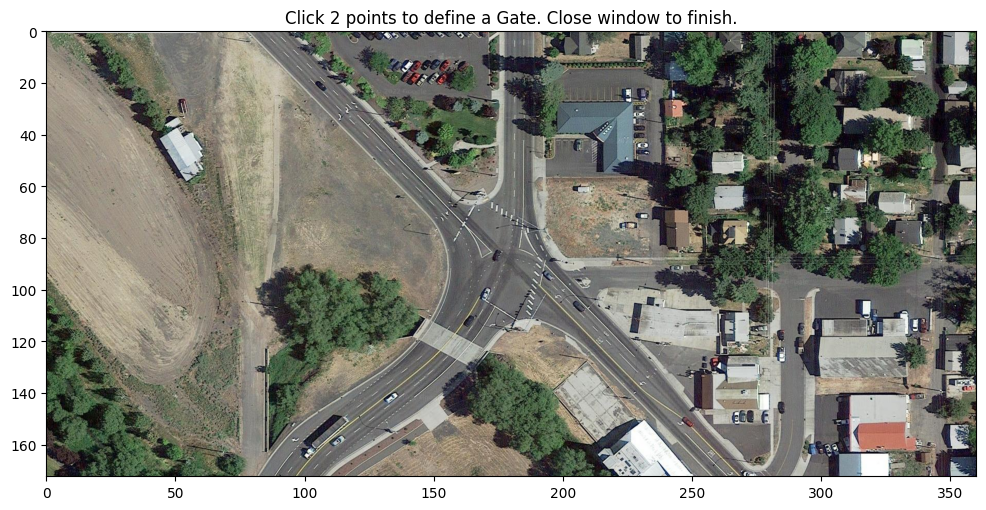

In [23]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import plotly.graph_objects as go
from shapely.geometry import LineString
from evo_fusion_visualizer import parse_xml_config, parse_and_align_data

# --- CONFIG ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"
GATE_TIME_TOLERANCE = 1.0 # Seconds (How close in time must the crossing be?)

def check_gate_crossings(df, gates):
    """
    Returns a list of crossing events:
    [{'ID': 123, 'Sensor': 0, 'Gate': 'S0_Entry', 'Time': 12:01:05}, ...]
    """
    print("--- Detecting Gate Crossings ---")
    crossings = []
    
    # Convert gates to Shapely objects for easy math
    gate_lines = {g['name']: LineString([g['p1'], g['p2']]) for g in gates}
    
    # Group by Object ID to get trajectory lines
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        if len(group) < 2: continue
        
        # Create a LineString from the trajectory
        # We simplify it slightly to speed up math
        points = list(zip(group['X'], group['Y']))
        trajectory = LineString(points)
        
        for g_name, g_line in gate_lines.items():
            if trajectory.intersects(g_line):
                # Find intersection point/time (approximate)
                # For simplicity, we just take the timestamp of the point closest to the gate
                # In a rigorous system, we'd interpolate the exact intersection timestamp.
                
                # Simple check: Which point is closest to the gate center?
                g_center = g_line.interpolate(0.5, normalized=True)
                
                # Calculate distances from all points to gate center
                dists = np.sqrt((group['X'] - g_center.x)**2 + (group['Y'] - g_center.y)**2)
                min_idx = dists.idxmin()
                
                cross_time = group.loc[min_idx, 'Time']
                
                crossings.append({
                    'ID': oid,
                    'Sensor': sensor,
                    'Gate': g_name,
                    'Time': cross_time
                })
                
    return pd.DataFrame(crossings)

def fuse_by_gates(df, crossings):
    print("--- Fusing based on Gates ---")
    
    # We look for pairs of objects that crossed "Linked Gates" at similar times.
    # User Logic: "If Object crosses S0_Gate and S1_Gate..."
    
    # 1. Define Logic Pairs (You can customize this or auto-detect)
    # For now, we look for ANY two objects crossing ANY two gates close in time
    # provided they are different sensors.
    
    matches = []
    
    # Sort crossings by time to find neighbors
    crossings = crossings.sort_values('Time')
    
    # Iterate
    for i in range(len(crossings)):
        c1 = crossings.iloc[i]
        
        # Look ahead in window
        subset = crossings[
            (crossings['Time'] > c1['Time'] - GATE_TIME_TOLERANCE) & 
            (crossings['Time'] < c1['Time'] + GATE_TIME_TOLERANCE)
        ]
        
        for j in range(len(subset)):
            c2 = subset.iloc[j]
            
            # Conditions for Fusion:
            # 1. Different Sensors
            # 2. Different IDs
            if c1['Sensor'] == c2['Sensor']: continue
            if c1['ID'] == c2['ID']: continue
            
            # 3. Found a match!
            matches.append({
                's1': c1['Sensor'], 'id1': c1['ID'],
                's2': c2['Sensor'], 'id2': c2['ID']
            })

    # Deduplicate matches
    # (Same logic as previous script to merge dataframes)
    # ... [Insert the same merge logic here, but using this 'matches' list] ...
    # For brevity, I will return the matches list so you can see it first.
    
    print(f"Found {len(matches)} Gate-Confirmed Handoffs.")
    return matches

if __name__ == "__main__":
    # Load
    cfg, img = parse_xml_config(XML_FILE)
    df = parse_and_align_data(DATA_FILE, cfg)
    
    with open(GATES_FILE, 'r') as f:
        gates = json.load(f)
        
    # Process
    events = check_gate_crossings(df, gates)
    matches = fuse_by_gates(df, events)
    
    print("Sample Matches:", matches[:5])
    # Next step: Plug 'matches' into the previous 'fuse_tracks' function

--- Detecting Gate Crossings ---
--- Fusing based on Gates ---
Found 194 Gate-Confirmed Handoffs.
Sample Matches: [{'s1': np.int64(1), 'id1': np.int64(754975), 's2': np.int64(0), 'id2': np.int64(918730)}, {'s1': np.int64(1), 'id1': np.int64(754741), 's2': np.int64(0), 'id2': np.int64(918730)}, {'s1': np.int64(1), 'id1': np.int64(754761), 's2': np.int64(0), 'id2': np.int64(918730)}, {'s1': np.int64(0), 'id1': np.int64(918730), 's2': np.int64(1), 'id2': np.int64(754975)}, {'s1': np.int64(0), 'id1': np.int64(918730), 's2': np.int64(1), 'id2': np.int64(754741)}]


In [35]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
COARSE_MATCH_DIST = 10.0   # Initial loose search radius for calibration
FINE_MATCH_DIST = 5.0      # Strict radius for final fusion matching
ISOLATION_RADIUS = 15.0    # "Clean data" must be this far from other cars
MIN_CALIB_POINTS = 10      # Need at least this many data points to build the bias map
SMOOTHING = 5.0            # RBF Smoothing factor (prevents overfitting to noise)

def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass
        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
    return config, img_b64

def load_gates(filepath, map_config):
    """Load gates and convert to map coordinates"""
    with open(filepath, 'r') as f:
        gates_raw = json.load(f)
    
    gates = []
    print("\n--- Loading Gates ---")
    
    for g in gates_raw:
        # Extract sensor from name (e.g., "S0_Gate" -> 0, "S1_Gate" -> 1)
        sensor = int(g['name'].split('_')[0][1:]) if g['name'].startswith('S') else None
        
        # Gates are in pixel coordinates - need to transform to map coordinates
        # Map coordinates = (pixel_coords - bg_offset) * scale
        p1_x = (g['p1'][0] - map_config['bg_off_x']) * map_config['scale']
        p1_y = (g['p1'][1] - map_config['bg_off_y']) * map_config['scale']
        p2_x = (g['p2'][0] - map_config['bg_off_x']) * map_config['scale']
        p2_y = (g['p2'][1] - map_config['bg_off_y']) * map_config['scale']
        
        p1 = (p1_x, p1_y)
        p2 = (p2_x, p2_y)
        
        gates.append({
            'name': g['name'],
            'sensor': sensor,
            'line': LineString([p1, p2]),
            'p1': p1,
            'p2': p2
        })
        
        print(f"   {g['name']} (S{sensor}):")
        print(f"      Raw pixels: ({g['p1'][0]:.1f}, {g['p1'][1]:.1f}) -> ({g['p2'][0]:.1f}, {g['p2'][1]:.1f})")
        print(f"      Map coords: ({p1_x:.1f}, {p1_y:.1f}) -> ({p2_x:.1f}, {p2_y:.1f})")
    
    return gates

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': None, 'y': None}
    
    print("--- Parsing Data File ---")
    
    # First pass: find S0 position
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('C;'):
                parts = line.split(';')
                if len(parts) > 1:
                    vals = parts[1].split(',')
                    if len(vals) >= 3:
                        try:
                            evo_s0['x'] = float(vals[0])
                            evo_s0['y'] = float(vals[1])
                            print(f"   Found S0 position: ({evo_s0['x']:.2f}, {evo_s0['y']:.2f})")
                            break
                        except:
                            pass
    
    if evo_s0['x'] is None: 
        print("   ⚠️ Warning: Could not find S0 position (C; line), using 0,0")
        evo_s0['x'] = 0
        evo_s0['y'] = 0
    
    # Global Offset (Rough Alignment)
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    print(f"   Translation: ({trans_x:.2f}, {trans_y:.2f})")

    # Second pass: extract object data
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    current_time = 0.0
    time_count = 0
    obj_count = 0
    
    for line in lines:
        line = line.strip()
        
        # Parse timestamp lines (format: HH:MM:SS.mmm)
        if ':' in line and '.' in line and len(line) < 20 and not line.startswith('F;'):
            try:
                # Handle format like "19:12:02.433"
                time_parts = line.split(':')
                if len(time_parts) == 3:
                    hours = float(time_parts[0])
                    minutes = float(time_parts[1])
                    seconds = float(time_parts[2])
                    current_time = hours * 3600 + minutes * 60 + seconds
                    time_count += 1
            except Exception as e:
                pass
            continue
        
        # Parse object data lines
        if line.startswith('F;'):
            parts = line.split(';')
            if len(parts) < 3:
                continue
                
            for ent in parts[4:]:  # Skip first 4 fields (F, frame_id, ?, ?)
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: 
                        sensor_id = sensor_id % 4 
                    
                    data.append({
                        'Time': current_time, 
                        'ID': oid, 
                        'X': x, 
                        'Y': y, 
                        'Sensor': sensor_id
                    })
                    obj_count += 1
                except Exception as e:
                    pass
    
    print(f"   Parsed {time_count} timestamps, {obj_count} object detections")
    
    df = pd.DataFrame(data)
    
    if df.empty:
        print("   ⚠️ ERROR: No data parsed! Check file format.")
        return df
    
    print(f"   DataFrame shape: {df.shape}")
    print(f"   Time range: {df['Time'].min():.2f} - {df['Time'].max():.2f}")
    print(f"   Sensors found: {sorted(df['Sensor'].unique())}")
    
    return df

# --- SPATIAL BIAS LEARNING ---
def train_spatial_bias_model(df):
    """
    Builds an RBF Interpolator to predict the error (dx, dy) 
    between sensors based on location (x, y).
    """
    print("--- Training Spatial Bias Model ---")
    
    df = df.sort_values('Time')
    times = df['Time'].unique()
    
    training_points = []
    calib_frames = times[::5] 
    
    print(f"   Scanning {len(calib_frames)} frames for isolated cars...")
    
    for t in calib_frames:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        
        if s0_objs.empty or other_objs.empty: continue
        
        for _, s0_row in s0_objs.iterrows():
            x0, y0 = s0_row['X'], s0_row['Y']
            
            # Isolation Check
            s0_dists = np.sqrt((s0_objs['X'] - x0)**2 + (s0_objs['Y'] - y0)**2)
            if np.sum(s0_dists < ISOLATION_RADIUS) > 1:
                continue 
            
            # Find Candidates in Other Sensors
            dists = np.sqrt((other_objs['X'] - x0)**2 + (other_objs['Y'] - y0)**2)
            
            min_idx = dists.idxmin()
            min_dist = dists[min_idx]
            
            if min_dist < COARSE_MATCH_DIST:
                match = other_objs.loc[min_idx]
                dx = x0 - match['X']
                dy = y0 - match['Y']
                
                training_points.append({
                    'x': match['X'], 'y': match['Y'], 
                    'dx': dx, 'dy': dy,
                    'sensor': match['Sensor']
                })

    print(f"   Found {len(training_points)} calibration points.")
    
    models = {}
    train_df = pd.DataFrame(training_points)
    
    if train_df.empty:
        print("⚠️ Not enough calibration data found. Using Raw alignment.")
        return None

    for sid in train_df['sensor'].unique():
        s_data = train_df[train_df['sensor'] == sid]
        if len(s_data) < MIN_CALIB_POINTS:
            print(f"   Skipping S{sid} (only {len(s_data)} points)")
            continue
            
        print(f"   Fitting Spatial Model for Sensor {sid} ({len(s_data)} pts)...")
        try:
            rbf_x = Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING)
            rbf_y = Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
            models[sid] = (rbf_x, rbf_y)
        except Exception as e:
            print(f"   RBF Error S{sid}: {e}")
            
    return models

def apply_spatial_correction(df, models):
    """
    Applies the learned RBF warp to align all sensors to S0.
    """
    if not models:
        df['CorrX'] = df['X']
        df['CorrY'] = df['Y']
        return df
        
    print("--- Applying Spatial Correction ---")
    
    corr_x_list = []
    corr_y_list = []
    
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        
        if sid == 0 or sid not in models:
            corr_x_list.append(x)
            corr_y_list.append(y)
        else:
            rbf_x, rbf_y = models[sid]
            dx = rbf_x(x, y)
            dy = rbf_y(x, y)
            
            corr_x_list.append(x + dx)
            corr_y_list.append(y + dy)
            
    df['CorrX'] = corr_x_list
    df['CorrY'] = corr_y_list
    return df

def check_gate_crossings(track_df, gates):
    """
    Check which gates a track crosses and return gate transitions.
    Returns: list of (sensor_label, time) for each crossing
    """
    crossings = []
    track_df = track_df.sort_values('Time').reset_index(drop=True)
    
    for i in range(len(track_df) - 1):
        p1 = Point(track_df.iloc[i]['CorrX'], track_df.iloc[i]['CorrY'])
        p2 = Point(track_df.iloc[i+1]['CorrX'], track_df.iloc[i+1]['CorrY'])
        segment = LineString([p1, p2])
        
        for gate in gates:
            if segment.intersects(gate['line']):
                crossings.append({
                    'sensor': gate['sensor'],
                    'time': track_df.iloc[i]['Time'],
                    'gate_name': gate['name']
                })
    
    return crossings

def classify_tracks_by_gates(df, gates):
    """
    Classify each track as:
    - 'entry': crosses from one sensor gate to another (needs fusion)
    - 'exit': the corresponding departure track
    - 'internal': stays within same sensor gates (ignore duplicates)
    """
    print("\n--- Classifying Tracks by Gate Crossings ---")
    print(f"   Gates in map coordinates:")
    for gate in gates:
        print(f"      {gate['name']} (S{gate['sensor']}): ({gate['p1'][0]:.1f}, {gate['p1'][1]:.1f}) -> ({gate['p2'][0]:.1f}, {gate['p2'][1]:.1f})")
    
    # Show data range
    print(f"\n   Track data range:")
    print(f"      X: {df['CorrX'].min():.1f} to {df['CorrX'].max():.1f}")
    print(f"      Y: {df['CorrY'].min():.1f} to {df['CorrY'].max():.1f}")
    
    tracks = {}
    total_tracks = 0
    
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        total_tracks += 1
        track = group.sort_values('Time').reset_index(drop=True)
        
        # Skip very short tracks
        if len(track) < 2:
            continue
            
        crossings = check_gate_crossings(track, gates)
        
        # Determine transition pattern
        sensors_crossed = [c['sensor'] for c in crossings]
        unique_sensors = set(sensors_crossed)
        
        track_type = 'unknown'
        if len(unique_sensors) > 1:
            # Crosses between different sensor gates
            track_type = 'transition'
        elif len(sensors_crossed) > 0:
            # Stays within same sensor
            track_type = 'internal'
        
        tracks[(sensor, oid)] = {
            'df': track,
            'type': track_type,
            'crossings': crossings,
            'sensors_crossed': sensors_crossed,
            'unique_sensors': unique_sensors
        }
    
    print(f"\n   Total tracks: {total_tracks}")
    print(f"   Tracks with 2+ points: {len(tracks)}")
    
    transition_count = sum(1 for t in tracks.values() if t['type'] == 'transition')
    internal_count = sum(1 for t in tracks.values() if t['type'] == 'internal')
    unknown_count = sum(1 for t in tracks.values() if t['type'] == 'unknown')
    
    print(f"   Transition tracks: {transition_count}")
    print(f"   Internal tracks: {internal_count}")
    print(f"   Unknown tracks: {unknown_count}")
    
    # Debug: show sample tracks
    if transition_count == 0 and internal_count == 0:
        print("\n   ⚠️ WARNING: No tracks crossing gates detected!")
        print("   Sample track analysis:")
        for i, (key, track) in enumerate(list(tracks.items())[:5]):
            sensor, oid = key
            df_t = track['df']
            print(f"\n   Track S{sensor}#{oid}:")
            print(f"      Points: {len(df_t)}")
            print(f"      X range: {df_t['CorrX'].min():.1f} to {df_t['CorrX'].max():.1f}")
            print(f"      Y range: {df_t['CorrY'].min():.1f} to {df_t['CorrY'].max():.1f}")
            print(f"      First point: ({df_t.iloc[0]['CorrX']:.1f}, {df_t.iloc[0]['CorrY']:.1f})")
            print(f"      Last point: ({df_t.iloc[-1]['CorrX']:.1f}, {df_t.iloc[-1]['CorrY']:.1f})")
            print(f"      Crossings: {len(track['crossings'])}")
            print(f"      Type: {track['type']}")
    
    return tracks

def fuse_tracks_with_gates(tracks):
    """
    Fuse tracks based on gate-crossing logic:
    - Only fuse tracks that show gate transitions
    - Use spatial proximity with corrected coordinates to find best match
    - If no gate crossings detected, fall back to showing all tracks
    """
    print("--- Fusing Transition Tracks ---")
    
    # Separate transition tracks by sensor
    transition_tracks = {k: v for k, v in tracks.items() if v['type'] == 'transition'}
    internal_tracks = {k: v for k, v in tracks.items() if v['type'] == 'internal'}
    unknown_tracks = {k: v for k, v in tracks.items() if v['type'] == 'unknown'}
    
    print(f"   Transition: {len(transition_tracks)}, Internal: {len(internal_tracks)}, Unknown: {len(unknown_tracks)}")
    
    # If no gate crossings detected, treat all tracks as "internal" for display
    if len(transition_tracks) == 0 and len(internal_tracks) == 0:
        print("   ⚠️ No gate crossings detected - displaying all tracks as raw data")
        internal_tracks = tracks
    
    matches = []
    consumed = set()
    
    # For each transition track, find its best match
    for key1, track1 in transition_tracks.items():
        if key1 in consumed:
            continue
            
        sensor1, id1 = key1
        df1 = track1['df']
        
        best_match = None
        best_overlap = 0
        
        # Look for matches in other sensors
        for key2, track2 in transition_tracks.items():
            if key2 in consumed or key2 == key1:
                continue
                
            sensor2, id2 = key2
            if sensor1 == sensor2:  # Same sensor, skip
                continue
                
            df2 = track2['df']
            
            # Find temporal overlap
            common_times = np.intersect1d(df1['Time'].values, df2['Time'].values)
            if len(common_times) < 3:
                continue
            
            # Check spatial proximity using corrected coordinates
            subset1 = df1[df1['Time'].isin(common_times)].reset_index(drop=True)
            subset2 = df2[df2['Time'].isin(common_times)].reset_index(drop=True)
            
            dists = np.sqrt((subset1['CorrX'].values - subset2['CorrX'].values)**2 + 
                           (subset1['CorrY'].values - subset2['CorrY'].values)**2)
            
            avg_dist = np.mean(dists)
            
            if avg_dist < FINE_MATCH_DIST and len(common_times) > best_overlap:
                best_overlap = len(common_times)
                best_match = (key2, track2, common_times, avg_dist)
        
        if best_match:
            key2, track2, common_times, avg_dist = best_match
            matches.append({
                'key1': key1,
                'key2': key2,
                'track1': track1,
                'track2': track2,
                'overlap_times': common_times,
                'avg_dist': avg_dist
            })
            consumed.add(key1)
            consumed.add(key2)
    
    print(f"   Created {len(matches)} fused track pairs")
    
    # Generate fused trajectories
    fused_data = []
    
    for m in matches:
        df1 = m['track1']['df']
        df2 = m['track2']['df']
        s1, id1 = m['key1']
        s2, id2 = m['key2']
        overlap = m['overlap_times']
        
        # Order by start time
        if df2['Time'].min() < df1['Time'].min():
            df1, df2 = df2, df1
            s1, s2 = s2, s1
            id1, id2 = id2, id1
        
        all_times = sorted(set(df1['Time']).union(set(df2['Time'])))
        overlap_start = overlap[0]
        overlap_end = overlap[-1]
        duration = overlap_end - overlap_start if overlap_end > overlap_start else 1
        
        for t in all_times:
            p1 = df1[df1['Time'] == t]
            p2 = df2[df2['Time'] == t]
            
            if not p1.empty and p2.empty:
                # Before handoff - use first sensor
                fused_data.append({
                    'Time': t,
                    'X': p1['CorrX'].values[0],
                    'Y': p1['CorrY'].values[0],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s1})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif p1.empty and not p2.empty:
                # After handoff - use second sensor
                fused_data.append({
                    'Time': t,
                    'X': p2['CorrX'].values[0],
                    'Y': p2['CorrY'].values[0],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s2})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif not p1.empty and not p2.empty:
                # Handoff zone - blend
                alpha = (t - overlap_start) / duration if duration > 0 else 0.5
                alpha = max(0.0, min(1.0, alpha))
                
                x = (1 - alpha) * p1['CorrX'].values[0] + alpha * p2['CorrX'].values[0]
                y = (1 - alpha) * p1['CorrY'].values[0] + alpha * p2['CorrY'].values[0]
                
                fused_data.append({
                    'Time': t,
                    'X': x,
                    'Y': y,
                    'Type': 'Fused',
                    'Hover': f"Handoff {alpha:.2f} ({id1}→{id2})",
                    'ColorID': f"{id1}_{id2}"
                })
    
    fused_df = pd.DataFrame(fused_data)
    
    # Keep internal and unconsumed tracks
    internal_data = []
    for key, track in tracks.items():
        if key not in consumed:
            df = track['df'].copy()
            sensor, oid = key
            
            # Use corrected coordinates for display
            for _, row in df.iterrows():
                internal_data.append({
                    'Time': row['Time'],
                    'X': row['CorrX'],
                    'Y': row['CorrY'],
                    'Type': track['type'],
                    'Hover': f"S{sensor} #{oid} ({track['type']})",
                    'ColorID': oid
                })
    
    internal_df = pd.DataFrame(internal_data)
    
    print(f"   Fused data points: {len(fused_df)}")
    print(f"   Internal data points: {len(internal_df)}")
    
    return fused_df, internal_df

def plot_final(fused, internal, map_config, bg_image, gates):
    print("--- Plotting ---")
    
    # Combine data
    if not fused.empty:
        fused['ColorVal'] = 'white'
    if not internal.empty:
        internal['ColorVal'] = internal.apply(lambda r: 
            {0:'cyan', 1:'yellow', 2:'lime', 3:'magenta'}.get(r['ColorID'] % 10, 'gray'), axis=1)
    
    df = pd.concat([internal, fused]) if not fused.empty else internal
    df = df.sort_values('Time')
    
    # Downsample for performance
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::2][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Gate-Based Fusion (White = Fused, Colors = Internal/Raw)"
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='black')))
    
    w = map_config['width'] * map_config['scale']
    h = map_config['height'] * map_config['scale']
    
    # Add gate lines
    for gate in gates:
        fig.add_shape(
            type="line",
            x0=gate['p1'][0], y0=gate['p1'][1],
            x1=gate['p2'][0], y1=gate['p2'][1],
            line=dict(color="red" if gate['sensor'] == 0 else "orange", width=3, dash="dash"),
            name=gate['name']
        )
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, 
                    sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    
    if fig.layout.updatemenus:
        fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100
    
    fig.write_html("fusion_gate_based.html")
    print("✓ Saved to fusion_gate_based.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_and_align_data(DATA_FILE, cfg)
    
    if df.empty:
        print("ERROR: No data loaded. Exiting.")
        exit(1)
    
    # 1. Learn spatial bias correction
    models = train_spatial_bias_model(df)
    
    # 2. Apply correction to all data
    df_corr = apply_spatial_correction(df, models)
    
    # 3. Classify tracks by gate crossings
    tracks = classify_tracks_by_gates(df_corr, gates)
    
    # 4. Fuse only transition tracks
    fused, internal = fuse_tracks_with_gates(tracks)
    
    # 5. Visualize
    plot_final(fused, internal, cfg, img, gates)


--- Loading Gates ---
   S1_Gate (S1):
      Raw pixels: (149.0, 82.6) -> (164.9, 57.1)
      Map coords: (-103.0, -106.3) -> (-99.8, -111.4)
   S0_Gate (S0):
      Raw pixels: (169.2, 52.8) -> (194.7, 65.2)
      Map coords: (-99.0, -112.2) -> (-93.9, -109.7)
   S0_Gate (S0):
      Raw pixels: (188.1, 118.6) -> (199.0, 88.0)
      Map coords: (-95.2, -99.1) -> (-93.0, -105.2)
   S0_Gate (S0):
      Raw pixels: (142.5, 106.2) -> (176.9, 133.3)
      Map coords: (-104.3, -101.5) -> (-97.4, -96.1)
--- Parsing Data File ---
   Found S0 position: (-1.52, -25.33)
   Translation: (172.71, 88.09)
   Parsed 6197 timestamps, 82405 object detections
   DataFrame shape: (82405, 5)
   Time range: 69122.43 - 69787.20
   Sensors found: [np.int64(0), np.int64(1)]
--- Training Spatial Bias Model ---
   Scanning 1239 frames for isolated cars...
   Found 854 calibration points.
   Fitting Spatial Model for Sensor 1.0 (854 pts)...
--- Applying Spatial Correction ---

--- Classifying Tracks by Gate Cross

In [40]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import os
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
ISOLATION_RADIUS = 15.0    
COARSE_MATCH_DIST = 10.0   
FINE_MATCH_DIST = 6.0      
DOWNSAMPLE = 2             

# --- 1. PARSING ---
def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass
        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content) or re.search(r'BackgroundImagePosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content) or re.search(r'BackgroundImagePosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
    return config, img_b64

def load_gates(filepath, map_config):
    # FALLBACK: Create default gates if missing
    if not os.path.exists(filepath):
        print("⚠️ No gates.json found. Generating defaults in METERS.")
        w = map_config.get('width', 1000) * map_config['scale']
        h = map_config.get('height', 1000) * map_config['scale']
        # Create a cross in the center
        return [
            {'name': 'S0_Default', 'sensor': 0, 'line': LineString([(w*0.2, h*0.5), (w*0.8, h*0.5)]), 'p1':(w*0.2, h*0.5), 'p2':(w*0.8, h*0.5)},
            {'name': 'S1_Default', 'sensor': 1, 'line': LineString([(w*0.5, h*0.2), (w*0.5, h*0.8)]), 'p1':(w*0.5, h*0.2), 'p2':(w*0.5, h*0.8)}
        ]
        
    with open(filepath, 'r') as f: gates_raw = json.load(f)
    gates = []
    print("\n--- Loading Gates ---")
    for g in gates_raw:
        sensor = 0
        if 'S1' in g['name']: sensor = 1
        elif 'S2' in g['name']: sensor = 2
        elif 'S3' in g['name']: sensor = 3
        
        # FIX: TRUST THE JSON COORDINATES (Assume they are already Meters)
        p1_x, p1_y = g['p1'][0], g['p1'][1]
        p2_x, p2_y = g['p2'][0], g['p2'][1]
        
        gates.append({
            'name': g['name'], 'sensor': sensor, 
            'line': LineString([(p1_x, p1_y), (p2_x, p2_y)]),
            'p1': (p1_x, p1_y), 'p2': (p2_x, p2_y)
        })
    return gates

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': 0, 'y': 0}
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('C;'):
                parts = line.split(';')
                if len(parts) > 1:
                    vals = parts[1].split(',')
                    if len(vals) >= 3:
                        evo_s0['x'] = float(vals[0])
                        evo_s0['y'] = float(vals[1])
                        break
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']

    with open(filepath, 'r') as f:
        lines = f.readlines()
    current_time = 0.0
    for line in lines:
        line = line.strip()
        if ':' in line and len(line) < 15:
            try:
                parts = line.split(':')
                current_time = float(parts[0])*3600 + float(parts[1])*60 + float(parts[2])
            except: pass
            continue
        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: sensor_id = sensor_id % 4 
                    data.append({'Time': current_time, 'ID': oid, 'X': x, 'Y': y, 'Sensor': sensor_id})
                except: pass
    return pd.DataFrame(data)

def verify_alignment(df, gates, map_config):
    """Sanity check to print coordinate ranges."""
    print("\n--- SANITY CHECK ---")
    
    # 1. Map Bounds
    w = map_config['width'] * map_config['scale']
    h = map_config['height'] * map_config['scale']
    print(f"Map Size (Meters): {w:.1f} x {h:.1f}")
    
    # 2. Data Bounds
    dx_min, dx_max = df['X'].min(), df['X'].max()
    dy_min, dy_max = df['Y'].min(), df['Y'].max()
    print(f"Data Bounds: X[{dx_min:.1f}, {dx_max:.1f}] Y[{dy_min:.1f}, {dy_max:.1f}]")
    
    # 3. Gate Bounds
    for g in gates:
        print(f"Gate '{g['name']}': ({g['p1'][0]:.1f}, {g['p1'][1]:.1f}) -> ({g['p2'][0]:.1f}, {g['p2'][1]:.1f})")
        if (g['p1'][0] < 0 or g['p1'][0] > w) or (g['p1'][1] < 0 or g['p1'][1] > h):
            print("  ⚠️ WARNING: Gate is OUTSIDE map bounds!")
            
    # Overlap Check
    if dx_max < 0 or dx_min > w or dy_max < 0 or dy_min > h:
         print("❌ CRITICAL: Data seems completely off the map.")
    else:
         print("✅ Data overlaps with map.")

# --- 2. SPATIAL BIAS ---
def train_spatial_bias(df):
    print("--- 1. Learning Spatial Bias ---")
    df = df.sort_values('Time')
    times = df['Time'].unique()
    training = []
    for t in times[::5]:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        if s0_objs.empty or other_objs.empty: continue
        for _, s0 in s0_objs.iterrows():
            if np.sum(np.sqrt((s0_objs['X']-s0['X'])**2 + (s0_objs['Y']-s0['Y'])**2) < ISOLATION_RADIUS) > 1: continue
            dists = np.sqrt((other_objs['X'] - s0['X'])**2 + (other_objs['Y'] - s0['Y'])**2)
            min_idx = dists.idxmin()
            if dists[min_idx] < COARSE_MATCH_DIST:
                match = other_objs.loc[min_idx]
                training.append({'x': match['X'], 'y': match['Y'], 'dx': s0['X'] - match['X'], 'dy': s0['Y'] - match['Y'], 'sensor': match['Sensor']})
    models = {}
    train_df = pd.DataFrame(training)
    if train_df.empty: return models
    for sid in train_df['sensor'].unique():
        s_data = train_df[train_df['sensor'] == sid]
        if len(s_data) > 5:
            try:
                models[sid] = (Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=5.0),
                               Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=5.0))
            except: pass
    return models

def apply_correction(df, models):
    if not models:
        df['CorrX'] = df['X']
        df['CorrY'] = df['Y']
        return df
    cx, cy = [], []
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        if sid != 0 and sid in models:
            rbf_x, rbf_y = models[sid]
            cx.append(x + rbf_x(x, y))
            cy.append(y + rbf_y(x, y))
        else:
            cx.append(x)
            cy.append(y)
    df['CorrX'] = cx
    df['CorrY'] = cy
    return df

# --- 3. STRICT GATE FUSION ---
def process_tracks(df, gates):
    print("--- 2. Processing Strict Gate Logic ---")
    
    raw_tracks = {}
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        track = group.sort_values('Time').reset_index(drop=True)
        crossings = []
        if len(track) > 1:
            for i in range(len(track)-1):
                p1 = Point(track.iloc[i]['CorrX'], track.iloc[i]['CorrY'])
                p2 = Point(track.iloc[i+1]['CorrX'], track.iloc[i+1]['CorrY'])
                seg = LineString([p1, p2])
                for gate in gates:
                    if seg.intersects(gate['line']):
                        crossings.append({'owner': gate['sensor'], 'time': track.iloc[i]['Time']})
        
        # STRICT FILTERING
        # 1. No Gates? -> Drop (Ghost)
        if not crossings:
            continue 
            
        # 2. Internal Path? -> Check Owner
        owners = set(c['owner'] for c in crossings)
        if len(owners) == 1:
            gate_owner = list(owners)[0]
            if sensor != gate_owner:
                continue # Drop (Ghost in another sensor's zone)
        
        raw_tracks[(sensor, oid)] = {'df': track, 'crossings': crossings}

    print(f"   Kept {len(raw_tracks)} valid tracks after filtering ghosts.")

    # FUSION LOGIC (Transitions)
    matches = []
    consumed = set()
    sensors = sorted(df['Sensor'].unique())
    
    for s1 in sensors:
        for s2 in sensors:
            if s1 >= s2: continue
            
            ids1 = [k for k in raw_tracks if k[0] == s1 and k not in consumed]
            ids2 = [k for k in raw_tracks if k[0] == s2 and k not in consumed]
            
            for k1 in ids1:
                for k2 in ids2:
                    t1 = raw_tracks[k1]['df']
                    t2 = raw_tracks[k2]['df']
                    
                    common = np.intersect1d(t1['Time'].values, t2['Time'].values)
                    if len(common) < 3: continue
                    
                    c1 = t1[t1['Time'].isin(common)]
                    c2 = t2[t2['Time'].isin(common)]
                    dist = np.mean(np.sqrt((c1['CorrX'].values - c2['CorrX'].values)**2 + (c1['CorrY'].values - c2['CorrY'].values)**2))
                    
                    if dist < FINE_MATCH_DIST:
                        matches.append({'k1': k1, 'k2': k2, 'overlap': common})
                        consumed.add(k1)
                        consumed.add(k2)

    final_rows = []
    
    # Process Matches
    for m in matches:
        k1, k2 = m['k1'], m['k2']
        t1, t2 = raw_tracks[k1], raw_tracks[k2]
        
        c1 = t1['crossings']
        c2 = t2['crossings']
        all_c = sorted(c1 + c2, key=lambda x: x['time'])
        
        start_owner = all_c[0]['owner']
        end_owner = all_c[-1]['owner']
        start_time = all_c[0]['time']
        end_time = all_c[-1]['time']
        duration = end_time - start_time
        if duration <= 0: duration = 1.0
        
        all_times = sorted(set(t1['df']['Time']).union(set(t2['df']['Time'])))
        
        for t in all_times:
            p1 = t1['df'][t1['df']['Time'] == t]
            p2 = t2['df'][t2['df']['Time'] == t]
            
            track_start = p1 if k1[0] == start_owner else p2
            track_end = p2 if k2[0] == end_owner else p1
            if k1[0] != start_owner and k2[0] != start_owner: 
                track_start, track_end = p1, p2

            alpha = (t - start_time) / duration
            alpha = max(0.0, min(1.0, alpha))
            w = alpha * alpha * (3 - 2 * alpha) 
            
            x, y, h = 0, 0, ""
            
            has_s = not track_start.empty
            has_e = not track_end.empty
            
            if has_s and has_e:
                x = (1-w)*track_start['CorrX'].values[0] + w*track_end['CorrX'].values[0]
                y = (1-w)*track_start['CorrY'].values[0] + w*track_end['CorrY'].values[0]
                h = f"Handoff {w:.2f}"
            elif has_s:
                x, y = track_start['CorrX'].values[0], track_start['CorrY'].values[0]
                h = f"Valid S{start_owner}"
            elif has_e:
                x, y = track_end['CorrX'].values[0], track_end['CorrY'].values[0]
                h = f"Valid S{end_owner}"
            
            final_rows.append({'Time': t, 'X': x, 'Y': y, 'Type': 'Fused', 'Hover': h, 'ColorID': f"F_{k1[1]}"})
            
    # Process Unmatched Valid Tracks
    for key, val in raw_tracks.items():
        if key in consumed: continue
        sensor, oid = key
        for _, row in val['df'].iterrows():
            final_rows.append({'Time': row['Time'], 'X': row['CorrX'], 'Y': row['CorrY'], 'Type': 'Internal', 'Hover': f"S{sensor} #{oid}", 'ColorID': oid})

    return pd.DataFrame(final_rows)

def plot_final(df, map_config, bg_image, gates):
    print("--- Plotting ---")
    if df.empty: return
    
    def get_color(row):
        if row['Type'] == 'Fused': return 'white'
        if 'S0' in row['Hover']: return 'cyan'
        if 'S1' in row['Hover']: return 'yellow'
        return 'lime'

    df['ColorVal'] = df.apply(get_color, axis=1)
    df = df.sort_values('Time')
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::DOWNSAMPLE][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Strict Gate Fusion (Fixed Coordinates)"
    )
    fig.update_traces(marker=dict(size=10, opacity=0.9, line=dict(width=1, color='black')))
    for g in gates:
        fig.add_shape(type="line", x0=g['p1'][0], y0=g['p1'][1], x1=g['p2'][0], y1=g['p2'][1],
            line=dict(color="orange", width=2, dash="dash"))
    w = map_config['width'] * map_config['scale']
    h = map_config['height'] * map_config['scale']
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100
    fig.write_html("fusion_fixed.html")
    print("✓ Saved to fusion_fixed.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_and_align_data(DATA_FILE, cfg)
    verify_alignment(df, gates, cfg) # <--- ADDED SANITY CHECK
    
    if not df.empty:
        models = train_spatial_bias(df)
        df_corr = apply_correction(df, models)
        final_df = process_tracks(df_corr, gates)
        plot_final(final_df, cfg, img, gates)


--- Loading Gates ---

--- SANITY CHECK ---
Map Size (Meters): 360.0 x 172.2
Data Bounds: X[-30.5, 372.3] Y[-380.6, 270.9]
Gate 'S1_Gate': (149.0, 82.6) -> (164.9, 57.1)
Gate 'S0_Gate': (169.2, 52.8) -> (194.7, 65.2)
Gate 'S0_Gate': (188.1, 118.6) -> (199.0, 88.0)
Gate 'S0_Gate': (142.5, 106.2) -> (176.9, 133.3)
✅ Data overlaps with map.
--- 1. Learning Spatial Bias ---
--- 2. Processing Strict Gate Logic ---
   Kept 279 valid tracks after filtering ghosts.
--- Plotting ---
✓ Saved to fusion_fixed.html


In [49]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import os
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
STITCH_TIME_THRESH = 2.0   # Seconds (Max gap to stitch broken tracks)
STITCH_DIST_THRESH = 15.0  # Meters (Max jump to stitch)
FINE_MATCH_DIST = 6.0      # Fusion radius (Meters)
ISOLATION_RADIUS = 15.0    # Calibration isolation (Meters)
SMOOTHING = 5.0            # RBF Smoothing
DOWNSAMPLE = 2             # Plot reduction

# --- 1. PARSING & ALIGNMENT ---
def parse_xml_config(filepath):
    # DEFAULT VALUES (Prevents KeyError if image fails)
    config = {
        'scale': 0.2, 
        'bg_off_x': 0, 'bg_off_y': 0, 
        's0_x': 0, 's0_y': 0,
        'width': 1000, 'height': 1000 # Safety defaults
    }
    img_b64 = None
    
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            
            # 1. Image & Dimensions
            m_img = re.search(r'BackgroundImage="([^"]+)"', content)
            if m_img: 
                img_b64 = "data:image/png;base64," + m_img.group(1)
                try:
                    img_bytes = base64.b64decode(m_img.group(1))
                    pil_img = Image.open(io.BytesIO(img_bytes))
                    config['width'] = pil_img.width
                    config['height'] = pil_img.height
                except: 
                    print("⚠️ Warning: Could not decode background image. Using default size.")

            # 2. Scale & Offsets
            m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
            if m_scale: config['scale'] = float(m_scale.group(1))
            
            m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content) or re.search(r'BackgroundImagePosX="([^"]+)"', content)
            if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
            
            m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content) or re.search(r'BackgroundImagePosY="([^"]+)"', content)
            if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
            
            # 3. Sensor 0 Anchor
            m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
            m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
            if m_s0x and m_s0y:
                config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
                config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
                
    except Exception as e:
        print(f"⚠️ Error parsing XML: {e}")
        
    return config, img_b64

def load_gates(filepath, map_config):
    if not os.path.exists(filepath):
        print("⚠️ No gates.json found.")
        return []
        
    with open(filepath, 'r') as f: gates_raw = json.load(f)
    gates = []
    print("\n--- Loading Gates ---")
    for g in gates_raw:
        sensor = 0
        if 'S1' in g['name']: sensor = 1
        elif 'S2' in g['name']: sensor = 2
        elif 'S3' in g['name']: sensor = 3
        
        # TRUST JSON METERS (Assuming created by tool)
        p1 = (g['p1'][0], g['p1'][1])
        p2 = (g['p2'][0], g['p2'][1])
        
        gates.append({
            'name': g['name'], 'owner': sensor,
            'line': LineString([p1, p2]), 'p1': p1, 'p2': p2
        })
    return gates

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': 0, 'y': 0}
    
    # 1. Find Anchor
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('C;'):
                    parts = line.split(';')
                    if len(parts) > 1:
                        vals = parts[1].split(',')
                        if len(vals) >= 3:
                            evo_s0['x'] = float(vals[0])
                            evo_s0['y'] = float(vals[1])
                            break
    except: pass
    
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']

    # 2. Parse Tracks
    try:
        with open(filepath, 'r') as f: lines = f.readlines()
    except: lines = []
        
    current_time = 0.0
    for line in lines:
        line = line.strip()
        if ':' in line and len(line) < 15:
            try:
                parts = line.split(':')
                current_time = float(parts[0])*3600 + float(parts[1])*60 + float(parts[2])
            except: pass
            continue
        
        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: sensor_id = sensor_id % 4 
                    
                    data.append({
                        'Time': current_time, 
                        'ID': oid, 
                        'X': x, 'Y': y, 
                        'Sensor': sensor_id
                    })
                except: pass
    
    return pd.DataFrame(data)

# --- 2. TRAJECTORY STITCHING ---
def stitch_broken_tracks(df):
    """
    Connects broken tracks (e.g., 918930 -> 919050) 
    if they are close in time/space and same sensor.
    """
    if df.empty: return df
    print("--- 1. Stitching Broken Trajectories ---")
    df = df.sort_values('Time')
    stitched_dfs = []
    
    for sensor, group in df.groupby('Sensor'):
        # Stats per ID
        track_stats = group.groupby('ID').agg(
            start_time=('Time', 'min'), end_time=('Time', 'max'),
            start_x=('X', 'first'), start_y=('Y', 'first'),
            end_x=('X', 'last'), end_y=('Y', 'last')
        ).reset_index().sort_values('start_time')
        
        id_map = {id: id for id in track_stats['ID']}
        consumed_starts = set()
        
        for i, row_a in track_stats.iterrows():
            id_a = row_a['ID']
            
            # Find candidate Track B starting after A ends
            candidates = track_stats[
                (track_stats['start_time'] > row_a['end_time']) & 
                (track_stats['start_time'] < row_a['end_time'] + STITCH_TIME_THRESH) &
                (~track_stats['ID'].isin(consumed_starts))
            ]
            if candidates.empty: continue
            
            # Distance Check
            dists = np.sqrt((candidates['start_x'] - row_a['end_x'])**2 + (candidates['start_y'] - row_a['end_y'])**2)
            if dists.min() < STITCH_DIST_THRESH:
                best_idx = dists.idxmin()
                id_b = candidates.loc[best_idx, 'ID']
                
                # Link B -> A (Chain mapping)
                root_id = id_map[id_a]
                id_map[id_b] = root_id
                consumed_starts.add(id_b)

        group_stitched = group.copy()
        group_stitched['ID'] = group_stitched['ID'].map(id_map)
        stitched_dfs.append(group_stitched)
        
    return pd.concat(stitched_dfs)

# --- 3. SPATIAL BIAS (RBF) ---
def train_spatial_bias(df):
    print("--- 2. Learning Spatial Bias ---")
    df = df.sort_values('Time')
    times = df['Time'].unique()
    training = []
    
    for t in times[::5]:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        if s0_objs.empty or other_objs.empty: continue
        
        for _, s0 in s0_objs.iterrows():
            if np.sum(np.sqrt((s0_objs['X']-s0['X'])**2 + (s0_objs['Y']-s0['Y'])**2) < ISOLATION_RADIUS) > 1: continue
            dists = np.sqrt((other_objs['X'] - s0['X'])**2 + (other_objs['Y'] - s0['Y'])**2)
            min_idx = dists.idxmin()
            if dists[min_idx] < 10.0:
                match = other_objs.loc[min_idx]
                training.append({'x': match['X'], 'y': match['Y'], 'dx': s0['X'] - match['X'], 'dy': s0['Y'] - match['Y'], 'sensor': match['Sensor']})
    
    models = {}
    train_df = pd.DataFrame(training)
    if train_df.empty: return models
    for sid in train_df['sensor'].unique():
        s_data = train_df[train_df['sensor'] == sid]
        if len(s_data) > 5:
            try:
                models[sid] = (
                    Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING),
                    Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
                )
            except: pass
    return models

def apply_correction(df, models):
    if not models:
        df['CorrX'] = df['X']; df['CorrY'] = df['Y']
        return df
    print("--- 3. Applying Spatial Correction ---")
    cx, cy = [], []
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        if sid != 0 and sid in models:
            rbf_x, rbf_y = models[sid]
            cx.append(x + rbf_x(x, y))
            cy.append(y + rbf_y(x, y))
        else:
            cx.append(x); cy.append(y)
    df['CorrX'] = cx; df['CorrY'] = cy
    return df

# --- 4. FUSION (HYBRID + VISUALIZATION) ---
def process_tracks_hybrid(df, gates):
    print("--- 4. Processing Fusion & Layering ---")
    raw_tracks = {}
    
    # A. Classify
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        track = group.sort_values('Time').reset_index(drop=True)
        if len(track) < 2: continue
        
        crossings = []
        for i in range(len(track)-1):
            p1 = Point(track.iloc[i]['CorrX'], track.iloc[i]['CorrY'])
            p2 = Point(track.iloc[i+1]['CorrX'], track.iloc[i+1]['CorrY'])
            seg = LineString([p1, p2])
            for gate in gates:
                if seg.intersects(gate['line']):
                    crossings.append({'owner': gate['owner'], 'time': track.iloc[i]['Time']})
        
        track_type = 'transition'
        if not crossings: track_type = 'no_cross' 
        else:
            owners = set(c['owner'] for c in crossings)
            if len(owners) == 1:
                gate_owner = list(owners)[0]
                track_type = 'internal_valid' if sensor == gate_owner else 'internal_ghost'

        if track_type != 'internal_ghost' and track_type != 'no_cross':
            raw_tracks[(sensor, oid)] = {'df': track, 'type': track_type, 'crossings': crossings}

    # B. Fuse Transitions
    transitions = {k: v for k, v in raw_tracks.items() if v['type'] == 'transition'}
    matches = []
    consumed = set()
    keys = list(transitions.keys())
    
    for i in range(len(keys)):
        k1 = keys[i]
        if k1 in consumed: continue
        t1 = transitions[k1]['df']
        best_match = None; best_dist = FINE_MATCH_DIST
        
        for j in range(i+1, len(keys)):
            k2 = keys[j]
            if k2 in consumed or k1[0] == k2[0]: continue
            t2 = transitions[k2]['df']
            
            common = np.intersect1d(t1['Time'].values, t2['Time'].values)
            if len(common) < 3: continue
            
            c1 = t1[t1['Time'].isin(common)]
            c2 = t2[t2['Time'].isin(common)]
            dist = np.mean(np.sqrt((c1['CorrX'].values - c2['CorrX'].values)**2 + (c1['CorrY'].values - c2['CorrY'].values)**2))
            
            if dist < best_dist:
                best_dist = dist; best_match = k2
        
        if best_match:
            matches.append({'k1': k1, 'k2': best_match})
            consumed.add(k1); consumed.add(best_match)

    # C. Generate Output Layers
    final_rows = []
    
    # 1. Matches (Inputs + Fused)
    for m in matches:
        k1, k2 = m['k1'], m['k2']
        t1, t2 = transitions[k1], transitions[k2]
        
        # Add INPUTS (Layer 1)
        for _, row in t1['df'].iterrows():
            final_rows.append({'Time': row['Time'], 'X': row['CorrX'], 'Y': row['CorrY'], 'Type': 'Input', 'Hover': f"Input S{k1[0]}", 'ColorID': k1[0]})
        for _, row in t2['df'].iterrows():
            final_rows.append({'Time': row['Time'], 'X': row['CorrX'], 'Y': row['CorrY'], 'Type': 'Input', 'Hover': f"Input S{k2[0]}", 'ColorID': k2[0]})

        # Add FUSED (Layer 2)
        c1_time = t1['crossings'][0]['time'] if t1['crossings'] else 0
        c2_time = t2['crossings'][0]['time'] if t2['crossings'] else 0
        if c2_time < c1_time: k1, k2 = k2, k1; t1, t2 = t2, t1
            
        start_owner = t1['crossings'][0]['owner']
        end_owner = t2['crossings'][-1]['owner']
        
        df1 = t1['df']; df2 = t2['df']
        all_times = sorted(set(df1['Time']).union(set(df2['Time'])))
        common = np.intersect1d(df1['Time'].values, df2['Time'].values)
        
        blend_start = common[0] if len(common)>0 else c1_time
        blend_duration = (common[-1] - common[0]) if len(common)>0 else 1.0
        if blend_duration <= 0: blend_duration = 1.0
            
        for t in all_times:
            p1 = df1[df1['Time'] == t]
            p2 = df2[df2['Time'] == t]
            has1, has2 = not p1.empty, not p2.empty
            x, y, h = 0, 0, ""
            
            if has1 and not has2:
                x, y, h = p1['CorrX'].values[0], p1['CorrY'].values[0], f"Valid S{start_owner}"
            elif not has1 and has2:
                x, y, h = p2['CorrX'].values[0], p2['CorrY'].values[0], f"Valid S{end_owner}"
            elif has1 and has2:
                alpha = max(0.0, min(1.0, (t - blend_start) / blend_duration))
                w = alpha * alpha * (3 - 2 * alpha)
                x = (1-w)*p1['CorrX'].values[0] + w*p2['CorrX'].values[0]
                y = (1-w)*p1['CorrY'].values[0] + w*p2['CorrY'].values[0]
                h = f"Handoff {w:.2f}"
            
            final_rows.append({'Time': t, 'X': x, 'Y': y, 'Type': 'Fused', 'Hover': h, 'ColorID': 'Fused'})

    # 2. Internal Tracks (Just themselves)
    for key, val in raw_tracks.items():
        if key in consumed: continue
        sensor, oid = key
        for _, row in val['df'].iterrows():
            final_rows.append({'Time': row['Time'], 'X': row['CorrX'], 'Y': row['CorrY'], 'Type': 'Internal', 'Hover': f"S{sensor} #{oid}", 'ColorID': sensor})

    return pd.DataFrame(final_rows)

def plot_final(df, map_config, bg_image, gates):
    print("--- 5. Plotting ---")
    if df.empty: 
        print("❌ Dataframe empty.")
        return
    
    # Colors: S0=Cyan, S1=Yellow. Fused=White.
    def get_color(row):
        if row['Type'] == 'Fused': return 'white'
        if row['ColorID'] == 0: return 'cyan'
        if row['ColorID'] == 1: return 'yellow'
        if row['ColorID'] == 2: return 'lime'
        return 'magenta'

    df['ColorVal'] = df.apply(get_color, axis=1)
    df = df.sort_values('Time')
    
    # Downsample
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::DOWNSAMPLE][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Fused Traffic (White=Result, Transparent=Inputs)"
    )
    
    # Style: Inputs are Faint, Fused/Internal are Solid
    fig.for_each_trace(lambda t: t.update(marker=dict(size=6, opacity=0.4)) if t.name != 'white' else t.update(marker=dict(size=12, opacity=1.0, line=dict(width=1, color='black'))))

    for g in gates:
        fig.add_shape(type="line", x0=g['p1'][0], y0=g['p1'][1], x1=g['p2'][0], y1=g['p2'][1],
            line=dict(color="orange", width=2, dash="dash"))
            
    w = map_config.get('width', 1000) * map_config['scale']
    h = map_config.get('height', 1000) * map_config['scale']
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100
    fig.write_html("fusion_complete_v2.html")
    print("✓ Saved to fusion_complete_v2.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_and_align_data(DATA_FILE, cfg)
    
    if not df.empty:
        df_stitched = stitch_broken_tracks(df)
        models = train_spatial_bias(df_stitched)
        df_corr = apply_correction(df_stitched, models)
        final_df = process_tracks_hybrid(df_corr, gates)
        plot_final(final_df, cfg, img, gates)


--- Loading Gates ---
--- 1. Stitching Broken Trajectories ---
--- 2. Learning Spatial Bias ---
--- 3. Applying Spatial Correction ---
--- 4. Processing Fusion & Layering ---
--- 5. Plotting ---
✓ Saved to fusion_complete_v2.html


In [53]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import os
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
SAME_SENSOR_STITCH_DIST = 15.0  # Gap to repair broken IDs (same sensor)
CROSS_SENSOR_MATCH_DIST = 8.0   # Gap to fuse S0->S1 (different sensors)
ISOLATION_RADIUS = 15.0         # For bias learning
SMOOTHING = 5.0                 # RBF Smoothing
DOWNSAMPLE = 2                  # Visualization subsample

# --- 1. UTILS & LOADING ---
def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0, 'width': 2000, 'height': 2000}
    img_b64 = None
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m_img = re.search(r'BackgroundImage="([^"]+)"', content)
            if m_img: 
                img_b64 = "data:image/png;base64," + m_img.group(1)
                try:
                    img_bytes = base64.b64decode(m_img.group(1))
                    pil_img = Image.open(io.BytesIO(img_bytes))
                    config['width'] = pil_img.width; config['height'] = pil_img.height
                except: pass
            m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
            if m_scale: config['scale'] = float(m_scale.group(1))
            m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content)
            if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
            m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content)
            if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
            m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
            m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
            if m_s0x and m_s0y:
                config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
                config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
    except: pass
    return config, img_b64

def load_gates(filepath, map_config):
    if not os.path.exists(filepath): return []
    with open(filepath, 'r') as f: gates_raw = json.load(f)
    gates = []
    print("\n--- Loading Gates (Meters) ---")
    for g in gates_raw:
        sensor = 0
        if 'S1' in g['name']: sensor = 1
        elif 'S2' in g['name']: sensor = 2
        elif 'S3' in g['name']: sensor = 3
        # Trust JSON meters
        p1 = (g['p1'][0], g['p1'][1])
        p2 = (g['p2'][0], g['p2'][1])
        gates.append({'name': g['name'], 'owner': sensor, 'line': LineString([p1, p2]), 'p1': p1, 'p2': p2})
    return gates

def parse_data(filepath, map_config):
    data = []
    evo_s0 = {'x': 0, 'y': 0}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('C;'):
                    parts = line.split(';')
                    if len(parts) > 1:
                        vals = parts[1].split(',')
                        if len(vals) >= 3:
                            evo_s0['x'] = float(vals[0]); evo_s0['y'] = float(vals[1])
                            break
    except: pass
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    
    try:
        with open(filepath, 'r') as f: lines = f.readlines()
    except: lines = []
    current_time = 0.0
    for line in lines:
        line = line.strip()
        if ':' in line and len(line) < 15:
            try:
                parts = line.split(':')
                current_time = float(parts[0])*3600 + float(parts[1])*60 + float(parts[2])
            except: pass
            continue
        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: sensor_id = sensor_id % 4 
                    data.append({'Time': current_time, 'ID': oid, 'X': x, 'Y': y, 'Sensor': sensor_id})
                except: pass
    return pd.DataFrame(data)

# --- 2. BIAS CORRECTION ---
def apply_spatial_correction(df):
    # Simple RBF alignment
    print("--- Calculating Spatial Correction ---")
    df = df.sort_values('Time').drop_duplicates(subset=['Sensor','ID','Time'])
    
    # 1. Find Calibration Points (Isolated cars)
    training = []
    times = df['Time'].unique()
    for t in times[::10]: # Fast scan
        frame = df[df['Time'] == t]
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        for _, s0 in s0_objs.iterrows():
            # Isolation check
            if np.sum(np.sqrt((s0_objs['X']-s0['X'])**2 + (s0_objs['Y']-s0['Y'])**2) < ISOLATION_RADIUS) > 1: continue
            # Match check
            dists = np.sqrt((other_objs['X']-s0['X'])**2 + (other_objs['Y']-s0['Y'])**2)
            if len(dists) > 0:
                min_idx = dists.idxmin()
                if dists[min_idx] < 10.0:
                    match = other_objs.loc[min_idx]
                    training.append({'x': match['X'], 'y': match['Y'], 'dx': s0['X']-match['X'], 'dy': s0['Y']-match['Y'], 'sensor': match['Sensor']})
    
    # 2. Train Models
    models = {}
    train_df = pd.DataFrame(training)
    if not train_df.empty:
        for sid in train_df['sensor'].unique():
            s_data = train_df[train_df['sensor'] == sid]
            if len(s_data) > 5:
                try:
                    models[sid] = (
                        Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING),
                        Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
                    )
                except: pass

    # 3. Apply
    cx, cy = [], []
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        if sid != 0 and sid in models:
            rbf_x, rbf_y = models[sid]
            cx.append(x + rbf_x(x, y))
            cy.append(y + rbf_y(x, y))
        else:
            cx.append(x); cy.append(y)
    df['CorrX'] = cx; df['CorrY'] = cy
    return df

# --- 3. THE "NO EXCEPTIONS" LOGIC ---
def process_strict_fusion(df, gates):
    print("--- Processing Strict Logic ---")
    
    # A. INITIAL REPAIR (Same-Sensor Stitching)
    # Merges 918930 -> 919050 if they are close (Time/Dist)
    stitched_tracks = []
    for sensor, group in df.groupby('Sensor'):
        # Sort and Calc Stats
        track_stats = group.groupby('ID').agg(
            start_time=('Time', 'min'), end_time=('Time', 'max'),
            start_x=('CorrX', 'first'), start_y=('CorrY', 'first'),
            end_x=('CorrX', 'last'), end_y=('CorrY', 'last')
        ).reset_index().sort_values('start_time')
        
        id_map = {id: id for id in track_stats['ID']}
        consumed = set()
        
        for i, row in track_stats.iterrows():
            if row['ID'] in consumed: continue
            # Look ahead for broken segment
            candidates = track_stats[
                (track_stats['start_time'] > row['end_time']) & 
                (track_stats['start_time'] < row['end_time'] + 2.0) # 2s gap
            ]
            if candidates.empty: continue
            
            dists = np.sqrt((candidates['start_x'] - row['end_x'])**2 + (candidates['start_y'] - row['end_y'])**2)
            if dists.min() < SAME_SENSOR_STITCH_DIST:
                match_id = candidates.loc[dists.idxmin(), 'ID']
                id_map[match_id] = row['ID'] # Merge
                consumed.add(match_id)
        
        group['ID'] = group['ID'].map(id_map)
        stitched_tracks.append(group)
    
    df_stitched = pd.concat(stitched_tracks)
    
    # B. ANALYZE TRACKS & GATES
    tracks = {} # Key: (Sensor, ID)
    for (sensor, oid), group in df_stitched.groupby(['Sensor', 'ID']):
        track = group.sort_values('Time').reset_index(drop=True)
        if len(track) < 2: continue
        
        # Check Gate Crossings
        crossings = []
        for i in range(len(track)-1):
            p1 = Point(track.iloc[i]['CorrX'], track.iloc[i]['CorrY'])
            p2 = Point(track.iloc[i+1]['CorrX'], track.iloc[i+1]['CorrY'])
            seg = LineString([p1, p2])
            for gate in gates:
                if seg.intersects(gate['line']):
                    crossings.append({'gate': gate['name'], 'owner': gate['owner'], 'time': track.iloc[i]['Time']})
        
        # Sort crossings by time
        crossings.sort(key=lambda x: x['time'])
        
        # Classify
        status = 'orphan' # Default: 1 gate or less
        if len(crossings) == 0: 
            status = 'noise'
        elif len(crossings) >= 2:
            owners = set(c['owner'] for c in crossings)
            if len(owners) == 1:
                # Internal (A->A)
                owner = list(owners)[0]
                status = 'valid' if sensor == owner else 'redundant_ghost'
            else:
                # Transition (A->B)
                status = 'transition'
        
        tracks[(sensor, oid)] = {'df': track, 'status': status, 'crossings': crossings}

    # C. FILTER & FUSE
    # "No track that only crosses one gate is valid. It either needs to be stitched or discarded."
    
    final_rows = []
    processed_keys = set()
    
    # 1. PROCESS TRANSITIONS (Fusion Candidates)
    # We look for overlapping transition tracks OR orphans that can form a transition
    
    # Get all tracks that aren't noise or redundant
    candidates = {k: v for k, v in tracks.items() if v['status'] in ['transition', 'orphan', 'valid']}
    candidate_keys = list(candidates.keys())
    
    for i in range(len(candidate_keys)):
        k1 = candidate_keys[i]
        if k1 in processed_keys: continue
        t1 = candidates[k1]
        
        # Look for match
        best_match = None
        best_dist = CROSS_SENSOR_MATCH_DIST
        
        for j in range(i+1, len(candidate_keys)):
            k2 = candidate_keys[j]
            if k2 in processed_keys: continue
            if k1[0] == k2[0]: continue # Must be diff sensors
            
            t2 = candidates[k2]
            
            # Check overlap
            df1 = t1['df']; df2 = t2['df']
            common = np.intersect1d(df1['Time'].values, df2['Time'].values)
            if len(common) < 3: continue
            
            c1 = df1[df1['Time'].isin(common)]
            c2 = df2[df2['Time'].isin(common)]
            dist = np.mean(np.sqrt((c1['CorrX'].values - c2['CorrX'].values)**2 + (c1['CorrY'].values - c2['CorrY'].values)**2))
            
            if dist < best_dist:
                best_dist = dist
                best_match = k2
                
        if best_match:
            # FUSE
            k2 = best_match
            processed_keys.add(k1)
            processed_keys.add(k2)
            t2 = candidates[k2]
            
            # Generate Fused Track
            # Add Inputs first (Transparent)
            for _, r in t1['df'].iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S{k1[0]}", 'ColorID':k1[0]})
            for _, r in t2['df'].iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S{k2[0]}", 'ColorID':k2[0]})
            
            # Weighted Average
            all_times = sorted(set(t1['df']['Time']).union(set(t2['df']['Time'])))
            for t in all_times:
                p1 = t1['df'][t1['df']['Time'] == t]
                p2 = t2['df'][t2['df']['Time'] == t]
                x, y, h = 0, 0, ""
                
                if not p1.empty and not p2.empty:
                    x = (p1['CorrX'].values[0] + p2['CorrX'].values[0])/2
                    y = (p1['CorrY'].values[0] + p2['CorrY'].values[0])/2
                    h = "Fused (Avg)"
                elif not p1.empty:
                    x, y, h = p1['CorrX'].values[0], p1['CorrY'].values[0], f"Fused (S{k1[0]} only)"
                elif not p2.empty:
                    x, y, h = p2['CorrX'].values[0], p2['CorrY'].values[0], f"Fused (S{k2[0]} only)"
                
                final_rows.append({'Time':t, 'X':x, 'Y':y, 'Type':'Fused', 'Hover':h, 'ColorID':'Fused'})
                
        else:
            # NO MATCH. Check "Complete Route" Logic
            # If it's an orphan (1 gate), DISCARD.
            if t1['status'] == 'orphan':
                pass # Discard
            elif t1['status'] == 'transition' or t1['status'] == 'valid':
                # Keep valid single routes (e.g. S0 sees both gates)
                processed_keys.add(k1)
                for _, r in t1['df'].iterrows():
                    final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Valid', 'Hover':f"Valid S{k1[0]}", 'ColorID':k1[0]})

    return pd.DataFrame(final_rows)

def plot_final(df, map_config, bg_image, gates):
    if df.empty: 
        print("❌ No valid tracks found. Check gates or thresholds.")
        return
        
    def get_color(row):
        if row['Type'] == 'Fused': return 'white'
        if row['ColorID'] == 0: return 'cyan'
        if row['ColorID'] == 1: return 'yellow'
        if row['ColorID'] == 2: return 'lime'
        return 'gray'

    df['ColorVal'] = df.apply(get_color, axis=1)
    df = df.sort_values('Time')
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::DOWNSAMPLE][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Strict Logic Fusion: No 1-Gate Tracks"
    )
    
    # Inputs = Faint, Valid/Fused = Solid
    fig.for_each_trace(lambda t: t.update(marker=dict(size=6, opacity=0.3)) if 'Input' in t.hovertext or t.name not in ['white'] else t.update(marker=dict(size=12, opacity=1.0, line=dict(width=1, color='black'))))
    
    for g in gates:
        fig.add_shape(type="line", x0=g['p1'][0], y0=g['p1'][1], x1=g['p2'][0], y1=g['p2'][1], line=dict(color="orange", width=2, dash="dash"))
            
    w = map_config.get('width', 2000) * map_config['scale']
    h = map_config.get('height', 2000) * map_config['scale']
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    fig.write_html("fusion_strict_logic.html")
    print("✓ Saved to fusion_strict_logic.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_data(DATA_FILE, cfg)
    
    if not df.empty:
        df_corr = apply_spatial_correction(df)
        final_df = process_strict_fusion(df_corr, gates)
        plot_final(final_df, cfg, img, gates)


--- Loading Gates (Meters) ---
--- Calculating Spatial Correction ---
--- Processing Strict Logic ---
✓ Saved to fusion_strict_logic.html


In [55]:
import pandas as pd
import numpy as np
import re
import json
import os
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
STITCH_TIME = 2.0       # Max gap to stitch broken IDs
STITCH_DIST = 15.0      # Max jump to stitch broken IDs
ISOLATION_RADIUS = 15.0 # For clean RBF learning
COARSE_MATCH = 10.0     # For RBF learning
FINE_MATCH = 6.0        # For final fusion
SMOOTHING = 5.0         # Warp smoothness
DOWNSAMPLE = 2          # Visualization speed

# --- 1. SETUP ---
def parse_xml_config(filepath):
    config = {'width': 2000, 'height': 2000, 'scale': 0.1, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
            if m_scale: config['scale'] = float(m_scale.group(1))
            m_bgx = re.search(r'BackgroundImagePosX="([^"]+)"', content)
            if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
            m_bgy = re.search(r'BackgroundImagePosY="([^"]+)"', content)
            if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
            m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
            if m_s0x: config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
            if m_s0y: config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
            
            # Attempt to find image dimensions (fallback to 2000x2000 if not found)
            m_w = re.search(r'Width="([^"]+)"', content)
            if m_w: config['width'] = float(m_w.group(1))
            m_h = re.search(r'Height="([^"]+)"', content)
            if m_h: config['height'] = float(m_h.group(1))
    except: pass
    return config, None # No image loading to avoid crash, we just need dims

def load_gates(filepath):
    if not os.path.exists(filepath): return []
    with open(filepath, 'r') as f: gates_raw = json.load(f)
    gates = []
    print("\n--- Loading Gates ---")
    for g in gates_raw:
        # Heuristic Owner: "S1_Entry" -> 1
        owner = 0
        if 'S1' in g['name']: owner = 1
        elif 'S2' in g['name']: owner = 2
        
        # Raw Meters (Trusted)
        p1 = (g['p1'][0], g['p1'][1])
        p2 = (g['p2'][0], g['p2'][1])
        
        gates.append({
            'name': g['name'], 'owner': owner, 
            'line': LineString([p1, p2]), 'p1': p1, 'p2': p2
        })
    return gates

def parse_data(filepath, map_config):
    data = []
    evo_s0 = {'x':0, 'y':0}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('C;'):
                    parts = line.split(';')
                    if len(parts)>1: vals=parts[1].split(','); evo_s0={'x':float(vals[0]), 'y':float(vals[1])}; break
    except: pass
    
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    
    with open(filepath, 'r') as f: lines = f.readlines()
    curr_time = 0.0
    for line in lines:
        if ':' in line and len(line)<15:
            try: p=line.strip().split(':'); curr_time=float(p[0])*3600+float(p[1])*60+float(p[2])
            except: pass
            continue
        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p)<4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sid = oid % 10
                    if sid > 3: sid = sid % 4
                    data.append({'Time': curr_time, 'ID': oid, 'X': x, 'Y': y, 'Sensor': sid})
                except: pass
    return pd.DataFrame(data)

# --- 2. LOGIC PIPELINE ---

def stitch_tracks(df):
    """ Step 1: Repair Broken IDs (Continuous Trajectories) """
    print("--- 1. Stitching Broken Tracks ---")
    df = df.sort_values('Time').drop_duplicates(subset=['ID', 'Time'])
    stitched_dfs = []
    
    for sensor, group in df.groupby('Sensor'):
        stats = group.groupby('ID').agg(
            t_end=('Time', 'max'), x_end=('X', 'last'), y_end=('Y', 'last'),
            t_start=('Time', 'min'), x_start=('X', 'first'), y_start=('Y', 'first')
        ).reset_index().sort_values('t_start')
        
        id_map = {i:i for i in stats['ID']}
        consumed = set()
        
        for i, row in stats.iterrows():
            if row['ID'] in consumed: continue
            candidates = stats[
                (stats['t_start'] > row['t_end']) & 
                (stats['t_start'] < row['t_end'] + STITCH_TIME) &
                (~stats['ID'].isin(consumed))
            ]
            if candidates.empty: continue
            
            dists = np.sqrt((candidates['x_start'] - row['x_end'])**2 + (candidates['y_start'] - row['y_end'])**2)
            if dists.min() < STITCH_DIST:
                match_id = candidates.loc[dists.idxmin(), 'ID']
                id_map[match_id] = id_map[row['ID']] # Chain map
                consumed.add(match_id)
        
        g = group.copy()
        g['ID'] = g['ID'].map(id_map)
        stitched_dfs.append(g)
        
    return pd.concat(stitched_dfs)

def train_and_apply_warp(df):
    """ Step 2: RBF Spatial Alignment (The missing piece!) """
    print("--- 2. Learning & Applying Spatial Warp ---")
    df = df.sort_values('Time')
    training = []
    times = df['Time'].unique()
    
    # 1. Learn
    for t in times[::10]:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        
        for _, s0 in s0_objs.iterrows():
            if np.sum(np.sqrt((s0_objs['X']-s0['X'])**2 + (s0_objs['Y']-s0['Y'])**2) < ISOLATION_RADIUS) > 1: continue
            
            dists = np.sqrt((other_objs['X'] - s0['X'])**2 + (other_objs['Y'] - s0['Y'])**2)
            if len(dists) > 0:
                min_idx = dists.idxmin()
                if dists[min_idx] < COARSE_MATCH:
                    match = other_objs.loc[min_idx]
                    training.append({
                        'x': match['X'], 'y': match['Y'], 
                        'dx': s0['X'] - match['X'], 'dy': s0['Y'] - match['Y'], 
                        'sensor': match['Sensor']
                    })
    
    models = {}
    train_df = pd.DataFrame(training)
    if not train_df.empty:
        for sid in train_df['sensor'].unique():
            s_data = train_df[train_df['sensor'] == sid]
            if len(s_data) > 5:
                try:
                    models[sid] = (
                        Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING),
                        Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
                    )
                except: pass

    # 2. Apply
    cx, cy = [], []
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        if sid != 0 and sid in models:
            rbf_x, rbf_y = models[sid]
            cx.append(x + rbf_x(x, y))
            cy.append(y + rbf_y(x, y))
        else:
            cx.append(x); cy.append(y)
    df['CorrX'] = cx; df['CorrY'] = cy
    return df

def strict_gate_fusion(df, gates):
    """ Step 3: Strict Domain Logic & Fusion on Warped Data """
    print("--- 3. Strict Gate Filtering & Fusion ---")
    
    tracks = {}
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        t = group.sort_values('Time').reset_index(drop=True)
        if len(t) < 2: continue
        
        # Check Gates using Warped Coords
        crossings = []
        path_line = LineString([Point(xy) for xy in zip(t['CorrX'], t['CorrY'])])
        for g in gates:
            if path_line.intersects(g['line']):
                crossings.append({'gate': g['name'], 'owner': g['owner']})
        
        # --- NO EXCEPTIONS LOGIC ---
        status = 'valid'
        if len(crossings) < 2:
            status = 'orphan' # < 2 gates -> Discard
        else:
            owners = set(c['owner'] for c in crossings)
            if len(owners) == 1:
                if sensor != list(owners)[0]: status = 'ghost' # S1 in S0 zone -> Discard
            else:
                status = 'transition' # Mixed owners -> Fuse
        
        if status not in ['orphan', 'ghost']:
            tracks[(sensor, oid)] = {'df': t, 'status': status}

    # Fuse
    final_rows = []
    processed = set()
    candidate_keys = list(tracks.keys())
    
    print(f"   Valid Candidates: {len(candidate_keys)}")
    
    for i in range(len(candidate_keys)):
        k1 = candidate_keys[i]
        if k1 in processed: continue
        t1 = tracks[k1]['df']
        
        best_match = None
        best_dist = FINE_MATCH
        
        for j in range(i+1, len(candidate_keys)):
            k2 = candidate_keys[j]
            if k2 in processed: continue
            if k1[0] == k2[0]: continue
            
            t2 = tracks[k2]['df']
            
            # Robust Overlap
            common = pd.merge(t1, t2, on='Time', suffixes=('_1', '_2'))
            if len(common) < 5: continue
            
            dist = np.mean(np.sqrt((common['CorrX_1']-common['CorrX_2'])**2 + (common['CorrY_1']-common['CorrY_2'])**2))
            if dist < best_dist:
                best_dist = dist
                best_match = k2
        
        if best_match:
            k2 = best_match
            processed.add(k1); processed.add(k2)
            t2 = tracks[k2]['df']
            
            # Add Transparent Inputs
            for _, r in t1.iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S{k1[0]}", 'ColorID':k1[0]})
            for _, r in t2.iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S{k2[0]}", 'ColorID':k2[0]})
            
            # Weighted Average Fusion
            all_times = sorted(set(t1['Time']).union(set(t2['Time'])))
            for t in all_times:
                p1 = t1[t1['Time']==t]
                p2 = t2[t2['Time']==t]
                x,y,h = 0,0,""
                
                if not p1.empty and not p2.empty:
                    x = (p1['CorrX'].values[0] + p2['CorrX'].values[0])/2
                    y = (p1['CorrY'].values[0] + p2['CorrY'].values[0])/2
                    h = "Fused"
                elif not p1.empty: x,y,h = p1['CorrX'].values[0], p1['CorrY'].values[0], f"Fused S{k1[0]}"
                elif not p2.empty: x,y,h = p2['CorrX'].values[0], p2['CorrY'].values[0], f"Fused S{k2[0]}"
                
                final_rows.append({'Time':t, 'X':x, 'Y':y, 'Type':'Fused', 'Hover':h, 'ColorID':'Fused'})
        else:
            # Unmatched but valid (e.g. S0 seeing S0->S0)
            processed.add(k1)
            for _, r in t1.iterrows():
                final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Valid', 'Hover':f"Valid S{k1[0]}", 'ColorID':k1[0]})

    return pd.DataFrame(final_rows)

def plot_final(df, map_config, bg_image, gates):
    if df.empty: 
        print("❌ Empty Result. Check Gates.")
        return
        
    def get_c(row):
        if row['Type'] == 'Fused': return 'white'
        return {0:'cyan', 1:'yellow', 2:'lime', 3:'magenta'}.get(row['ColorID'], 'gray')

    df['ColorVal'] = df.apply(get_c, axis=1)
    df = df.sort_values('Time')
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::DOWNSAMPLE][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover', 
        color_discrete_map='identity',
        title="Ultimate Fusion: Stitch + Warp + Strict Gates"
    )
    
    # Inputs=Transp, Fused=Solid
    fig.for_each_trace(lambda t: t.update(marker=dict(size=6, opacity=0.3)) if 'Input' in t.hovertext or t.name != 'white' else t.update(marker=dict(size=12, opacity=1.0, line=dict(width=1, color='black'))))
    
    for g in gates:
        fig.add_shape(type="line", x0=g['p1'][0], y0=g['p1'][1], x1=g['p2'][0], y1=g['p2'][1], line=dict(color="orange", width=2, dash="dash"))
    
    w = map_config.get('width', 2000) * map_config['scale']
    h = map_config.get('height', 2000) * map_config['scale']
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    fig.write_html("fusion_ultimate.html")
    print("✓ Saved to fusion_ultimate.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE)
    df = parse_data(DATA_FILE, cfg)
    
    if not df.empty:
        df = stitch_tracks(df)          # 1. Stitch
        df = train_and_apply_warp(df)   # 2. Warp
        df = strict_gate_fusion(df, gates) # 3. Strict Filter & Fuse
        plot_final(df, cfg, img, gates)


--- Loading Gates ---
--- 1. Stitching Broken Tracks ---
--- 2. Learning & Applying Spatial Warp ---
--- 3. Strict Gate Filtering & Fusion ---
   Valid Candidates: 17
✓ Saved to fusion_ultimate.html


In [57]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
COARSE_MATCH_DIST = 10.0   # Initial loose search radius for calibration
FINE_MATCH_DIST = 5.0      # Strict radius for final fusion matching
ISOLATION_RADIUS = 15.0    # "Clean data" must be this far from other cars
MIN_CALIB_POINTS = 10      # Need at least this many data points to build the bias map
SMOOTHING = 5.0            # RBF Smoothing factor (prevents overfitting to noise)

def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass
        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
    return config, img_b64

def load_gates(filepath, map_config):
    """
    Load gates and transform from display coordinates to track coordinates.
    Gates are defined in display space (0,0 = top-left of background image).
    Tracks are in sensor-relative space after alignment.
    """
    with open(filepath, 'r') as f:
        gates_raw = json.load(f)
    
    gates = []
    print("\n--- Loading Gates ---")
    print(f"   S0 sensor position in map coords: ({map_config['s0_x']:.1f}, {map_config['s0_y']:.1f})")
    
    for g in gates_raw:
        # Extract sensor from name (e.g., "S0_Gate" -> 0, "S1_Gate" -> 1)
        sensor = int(g['name'].split('_')[0][1:]) if g['name'].startswith('S') else None
        
        # Gates were drawn in display coordinates (map image space)
        # We need to transform them to match the track coordinate system
        # The track data has been shifted so S0 is at map_config['s0_x'], map_config['s0_y']
        # But the gates are relative to the background image origin
        # So we DON'T apply any additional transformation - gates and tracks should already align
        # because tracks were aligned TO the map via: trans_x = map_config['s0_x'] - evo_s0['x']
        
        p1 = (g['p1'][0], g['p1'][1])
        p2 = (g['p2'][0], g['p2'][1])
        
        gates.append({
            'name': g['name'],
            'sensor': sensor,
            'line': LineString([p1, p2]),
            'p1': p1,
            'p2': p2
        })
        
        print(f"   {g['name']} (S{sensor}): ({p1[0]:.1f}, {p1[1]:.1f}) -> ({p2[0]:.1f}, {p2[1]:.1f})")
    
    return gates

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': None, 'y': None}
    
    print("--- Parsing Data File ---")
    
    # First pass: find S0 position
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('C;'):
                parts = line.split(';')
                if len(parts) > 1:
                    vals = parts[1].split(',')
                    if len(vals) >= 3:
                        try:
                            evo_s0['x'] = float(vals[0])
                            evo_s0['y'] = float(vals[1])
                            print(f"   Found S0 position: ({evo_s0['x']:.2f}, {evo_s0['y']:.2f})")
                            break
                        except:
                            pass
    
    if evo_s0['x'] is None: 
        print("   ⚠️ Warning: Could not find S0 position (C; line), using 0,0")
        evo_s0['x'] = 0
        evo_s0['y'] = 0
    
    # Global Offset (Rough Alignment)
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    print(f"   Translation: ({trans_x:.2f}, {trans_y:.2f})")

    # Second pass: extract object data
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    current_time = 0.0
    time_count = 0
    obj_count = 0
    
    for line in lines:
        line = line.strip()
        
        # Parse timestamp lines (format: HH:MM:SS.mmm)
        if ':' in line and '.' in line and len(line) < 20 and not line.startswith('F;'):
            try:
                # Handle format like "19:12:02.433"
                time_parts = line.split(':')
                if len(time_parts) == 3:
                    hours = float(time_parts[0])
                    minutes = float(time_parts[1])
                    seconds = float(time_parts[2])
                    current_time = hours * 3600 + minutes * 60 + seconds
                    time_count += 1
            except Exception as e:
                pass
            continue
        
        # Parse object data lines
        if line.startswith('F;'):
            parts = line.split(';')
            if len(parts) < 3:
                continue
                
            for ent in parts[4:]:  # Skip first 4 fields (F, frame_id, ?, ?)
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: 
                        sensor_id = sensor_id % 4 
                    
                    data.append({
                        'Time': current_time, 
                        'ID': oid, 
                        'X': x, 
                        'Y': y, 
                        'Sensor': sensor_id
                    })
                    obj_count += 1
                except Exception as e:
                    pass
    
    print(f"   Parsed {time_count} timestamps, {obj_count} object detections")
    
    df = pd.DataFrame(data)
    
    if df.empty:
        print("   ⚠️ ERROR: No data parsed! Check file format.")
        return df
    
    print(f"   DataFrame shape: {df.shape}")
    print(f"   Time range: {df['Time'].min():.2f} - {df['Time'].max():.2f}")
    print(f"   Sensors found: {sorted(df['Sensor'].unique())}")
    
    return df

# --- SPATIAL BIAS LEARNING ---
def train_spatial_bias_model(df):
    """
    Builds an RBF Interpolator to predict the error (dx, dy) 
    between sensors based on location (x, y).
    """
    print("--- Training Spatial Bias Model ---")
    
    df = df.sort_values('Time')
    times = df['Time'].unique()
    
    training_points = []
    calib_frames = times[::5] 
    
    print(f"   Scanning {len(calib_frames)} frames for isolated cars...")
    
    for t in calib_frames:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        
        if s0_objs.empty or other_objs.empty: continue
        
        for _, s0_row in s0_objs.iterrows():
            x0, y0 = s0_row['X'], s0_row['Y']
            
            # Isolation Check
            s0_dists = np.sqrt((s0_objs['X'] - x0)**2 + (s0_objs['Y'] - y0)**2)
            if np.sum(s0_dists < ISOLATION_RADIUS) > 1:
                continue 
            
            # Find Candidates in Other Sensors
            dists = np.sqrt((other_objs['X'] - x0)**2 + (other_objs['Y'] - y0)**2)
            
            min_idx = dists.idxmin()
            min_dist = dists[min_idx]
            
            if min_dist < COARSE_MATCH_DIST:
                match = other_objs.loc[min_idx]
                dx = x0 - match['X']
                dy = y0 - match['Y']
                
                training_points.append({
                    'x': match['X'], 'y': match['Y'], 
                    'dx': dx, 'dy': dy,
                    'sensor': match['Sensor']
                })

    print(f"   Found {len(training_points)} calibration points.")
    
    models = {}
    train_df = pd.DataFrame(training_points)
    
    if train_df.empty:
        print("⚠️ Not enough calibration data found. Using Raw alignment.")
        return None

    for sid in train_df['sensor'].unique():
        s_data = train_df[train_df['sensor'] == sid]
        if len(s_data) < MIN_CALIB_POINTS:
            print(f"   Skipping S{sid} (only {len(s_data)} points)")
            continue
            
        print(f"   Fitting Spatial Model for Sensor {sid} ({len(s_data)} pts)...")
        try:
            rbf_x = Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING)
            rbf_y = Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
            models[sid] = (rbf_x, rbf_y)
        except Exception as e:
            print(f"   RBF Error S{sid}: {e}")
            
    return models

def apply_spatial_correction(df, models):
    """
    Applies the learned RBF warp to align all sensors to S0.
    """
    if not models:
        df['CorrX'] = df['X']
        df['CorrY'] = df['Y']
        return df
        
    print("--- Applying Spatial Correction ---")
    
    corr_x_list = []
    corr_y_list = []
    
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        
        if sid == 0 or sid not in models:
            corr_x_list.append(x)
            corr_y_list.append(y)
        else:
            rbf_x, rbf_y = models[sid]
            dx = rbf_x(x, y)
            dy = rbf_y(x, y)
            
            corr_x_list.append(x + dx)
            corr_y_list.append(y + dy)
            
    df['CorrX'] = corr_x_list
    df['CorrY'] = corr_y_list
    return df

def check_gate_crossings(track_df, gates):
    """
    Check which gates a track crosses and return gate transitions.
    Returns: list of (sensor_label, time) for each crossing
    """
    crossings = []
    track_df = track_df.sort_values('Time').reset_index(drop=True)
    
    for i in range(len(track_df) - 1):
        p1 = Point(track_df.iloc[i]['CorrX'], track_df.iloc[i]['CorrY'])
        p2 = Point(track_df.iloc[i+1]['CorrX'], track_df.iloc[i+1]['CorrY'])
        segment = LineString([p1, p2])
        
        for gate in gates:
            if segment.intersects(gate['line']):
                crossings.append({
                    'sensor': gate['sensor'],
                    'time': track_df.iloc[i]['Time'],
                    'gate_name': gate['name']
                })
    
    return crossings

def stitch_fragments(tracks, gates):
    """
    Try to connect fragment tracks that are likely the same object.
    Look for fragments where one ends and another begins nearby in space and time.
    """
    print("\n--- Stitching Fragment Tracks ---")
    
    fragments = {k: v for k, v in tracks.items() if v['type'] == 'fragment'}
    stitched_count = 0
    
    if not fragments:
        print("   No fragments to stitch")
        return tracks
    
    print(f"   Processing {len(fragments)} fragments...")
    
    # Parameters for stitching
    MAX_TIME_GAP = 2.0  # seconds
    MAX_SPATIAL_GAP = 15.0  # meters
    
    stitched = {}
    consumed = set()
    
    for key1, frag1 in fragments.items():
        if key1 in consumed:
            continue
            
        df1 = frag1['df']
        end_time = df1['Time'].max()
        end_x = df1[df1['Time'] == end_time]['CorrX'].values[0]
        end_y = df1[df1['Time'] == end_time]['CorrY'].values[0]
        
        # Look for a fragment that starts shortly after this one ends
        best_match = None
        best_score = float('inf')
        
        for key2, frag2 in fragments.items():
            if key2 == key1 or key2 in consumed:
                continue
            
            df2 = frag2['df']
            start_time = df2['Time'].min()
            start_x = df2[df2['Time'] == start_time]['CorrX'].values[0]
            start_y = df2[df2['Time'] == start_time]['CorrY'].values[0]
            
            time_gap = start_time - end_time
            spatial_gap = np.sqrt((start_x - end_x)**2 + (start_y - end_y)**2)
            
            if 0 < time_gap < MAX_TIME_GAP and spatial_gap < MAX_SPATIAL_GAP:
                # Score: prefer closer in both time and space
                score = time_gap + spatial_gap
                if score < best_score:
                    best_score = score
                    best_match = (key2, frag2)
        
        if best_match:
            key2, frag2 = best_match
            
            # Stitch them together
            df_combined = pd.concat([df1, frag2['df']]).sort_values('Time').reset_index(drop=True)
            
            # Use the tracking sensor from the first fragment
            tracking_sensor = key1[0]
            
            # Re-check gate crossings for the combined track
            crossings = check_gate_crossings(df_combined, gates)
            gates_crossed = set((c['sensor'], c['gate_name']) for c in crossings)
            sensors_crossed = set(c['sensor'] for c in crossings)
            num_gates = len(gates_crossed)
            
            # Reclassify with sensor matching logic
            track_type = 'fragment'
            if num_gates >= 2:
                if len(sensors_crossed) == 1:
                    gate_sensor = list(sensors_crossed)[0]
                    if gate_sensor == tracking_sensor:
                        track_type = 'valid_internal'
                    else:
                        track_type = 'transition'
                else:
                    track_type = 'transition'
            elif num_gates == 1:
                gate_sensor = list(sensors_crossed)[0] if sensors_crossed else None
                if gate_sensor == tracking_sensor:
                    track_type = 'fragment'
                else:
                    track_type = 'transition'
            
            # Create stitched track
            stitched_key = (tracking_sensor, f"{key1[1]}_stitched_{key2[1]}")
            stitched[stitched_key] = {
                'df': df_combined,
                'type': track_type,
                'crossings': crossings,
                'gates_crossed': gates_crossed,
                'sensors_crossed': sensors_crossed,
                'num_gates': num_gates,
                'tracking_sensor': tracking_sensor
            }
            
            consumed.add(key1)
            consumed.add(key2)
            stitched_count += 1
    
    # Update tracks: remove consumed fragments, add stitched tracks
    new_tracks = {k: v for k, v in tracks.items() if k not in consumed}
    new_tracks.update(stitched)
    
    print(f"   Stitched {stitched_count} fragment pairs")
    print(f"   Remaining fragments: {sum(1 for t in new_tracks.values() if t['type'] == 'fragment')}")
    
    return new_tracks

def classify_tracks_by_gates(df, gates):
    """
    Classify each track based on gate crossings:
    - 'valid_internal': crosses 2+ gates from SAME sensor AND tracking sensor matches gate sensor
    - 'transition': crosses gates from DIFFERENT sensors OR tracking sensor doesn't match gate sensor
    - 'fragment': crosses only 1 gate (keep for handoff matching, don't discard)
    """
    print("\n--- Classifying Tracks by Gate Crossings ---")
    print(f"   Gates in map coordinates:")
    for gate in gates:
        print(f"      {gate['name']} (S{gate['sensor']}): ({gate['p1'][0]:.1f}, {gate['p1'][1]:.1f}) -> ({gate['p2'][0]:.1f}, {gate['p2'][1]:.1f})")
    
    # Show data range
    print(f"\n   Track data range:")
    print(f"      X: {df['CorrX'].min():.1f} to {df['CorrX'].max():.1f}")
    print(f"      Y: {df['CorrY'].min():.1f} to {df['CorrY'].max():.1f}")
    
    tracks = {}
    
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        track = group.sort_values('Time').reset_index(drop=True)
        
        # Skip very short tracks
        if len(track) < 2:
            continue
            
        crossings = check_gate_crossings(track, gates)
        
        # Count unique gates crossed
        gates_crossed = set((c['sensor'], c['gate_name']) for c in crossings)
        sensors_crossed = set(c['sensor'] for c in crossings)
        num_gates = len(gates_crossed)
        
        # Classify based on:
        # 1. How many gates crossed
        # 2. Whether gate sensors match tracking sensor
        # 3. Whether multiple gate sensors involved
        
        track_type = 'fragment'  # Default
        
        if num_gates >= 2:
            # Check if all gates belong to the same sensor
            if len(sensors_crossed) == 1:
                gate_sensor = list(sensors_crossed)[0]
                
                # Valid internal: tracking sensor matches gate sensor
                if gate_sensor == sensor:
                    track_type = 'valid_internal'
                else:
                    # Sensor mismatch: S1 tracking across S0 gates = redundant/transition
                    track_type = 'transition'
            else:
                # Crosses gates from different sensors = transition
                track_type = 'transition'
        elif num_gates == 1:
            # Single gate crossing
            gate_sensor = list(sensors_crossed)[0] if sensors_crossed else None
            
            if gate_sensor == sensor:
                # Same sensor: keep as fragment for handoff matching
                track_type = 'fragment'
            else:
                # Different sensor: this is a transition candidate
                track_type = 'transition'
        # else: num_gates == 0, remains 'fragment'
        
        tracks[(sensor, oid)] = {
            'df': track,
            'type': track_type,
            'crossings': crossings,
            'gates_crossed': gates_crossed,
            'sensors_crossed': sensors_crossed,
            'num_gates': num_gates,
            'tracking_sensor': sensor
        }
    
    print(f"\n   Total tracks processed: {len(tracks)}")
    
    valid_count = sum(1 for t in tracks.values() if t['type'] == 'valid_internal')
    transition_count = sum(1 for t in tracks.values() if t['type'] == 'transition')
    fragment_count = sum(1 for t in tracks.values() if t['type'] == 'fragment')
    
    print(f"   Valid internal tracks: {valid_count}")
    print(f"   Transition tracks (need fusion): {transition_count}")
    print(f"   Fragments (for handoff matching): {fragment_count}")
    
    return tracks

def fuse_tracks_with_gates(tracks):
    """
    Fuse tracks based on gate-crossing logic:
    - Valid internal tracks: keep as-is (S0 tracking across S0 gates)
    - Transition tracks: fuse across sensors OR discard if redundant
    - Fragments: use for handoff matching, then discard if unmatched
    
    Key insight: If S1 tracks across S0 gates, it's redundant (S0 should see it).
                 Only fuse when there's a legitimate handoff between sensor zones.
    """
    print("\n--- Fusing Transition Tracks ---")
    
    valid_internal = {k: v for k, v in tracks.items() if v['type'] == 'valid_internal'}
    transition_tracks = {k: v for k, v in tracks.items() if v['type'] == 'transition'}
    fragments = {k: v for k, v in tracks.items() if v['type'] == 'fragment'}
    
    print(f"   Valid internal: {len(valid_internal)}")
    print(f"   Transitions (need fusion/discard): {len(transition_tracks)}")
    print(f"   Fragments (for handoff): {len(fragments)}")
    
    # Separate transitions into:
    # 1. Cross-sensor transitions (S0→S1 gates): need fusion
    # 2. Redundant tracks (S1 tracking S0 gates): discard
    
    cross_sensor = {}
    redundant = {}
    
    for key, track in transition_tracks.items():
        tracking_sensor = track['tracking_sensor']
        sensors_in_gates = track['sensors_crossed']
        
        # If track crosses gates from different sensors, it's a genuine transition
        if len(sensors_in_gates) > 1:
            cross_sensor[key] = track
        else:
            # Only one gate sensor, but doesn't match tracking sensor
            gate_sensor = list(sensors_in_gates)[0]
            if gate_sensor != tracking_sensor:
                # E.g., S1 tracking across S0 gates = redundant
                redundant[key] = track
            else:
                # This shouldn't happen based on classification, but keep it safe
                cross_sensor[key] = track
    
    print(f"   Cross-sensor transitions: {len(cross_sensor)}")
    print(f"   Redundant (will discard): {len(redundant)}")
    
    # Combine cross-sensor transitions and fragments for fusion matching
    fusion_candidates = {**cross_sensor, **fragments}
    
    matches = []
    consumed = set()
    
    # Match tracks that should be fused (handoffs between sensors)
    for key1, track1 in fusion_candidates.items():
        if key1 in consumed:
            continue
            
        sensor1, id1 = key1
        df1 = track1['df']
        
        best_match = None
        best_overlap = 0
        
        # Look for matches in other sensors
        for key2, track2 in fusion_candidates.items():
            if key2 in consumed or key2 == key1:
                continue
                
            sensor2, id2 = key2
            if sensor1 == sensor2:  # Same sensor, skip
                continue
                
            df2 = track2['df']
            
            # Find temporal overlap
            common_times = np.intersect1d(df1['Time'].values, df2['Time'].values)
            if len(common_times) < 3:
                continue
            
            # Check spatial proximity using corrected coordinates
            # Make sure to handle duplicates by taking only the first occurrence
            subset1 = df1[df1['Time'].isin(common_times)].drop_duplicates('Time').sort_values('Time').reset_index(drop=True)
            subset2 = df2[df2['Time'].isin(common_times)].drop_duplicates('Time').sort_values('Time').reset_index(drop=True)
            
            # Ensure they have the same length after deduplication
            min_len = min(len(subset1), len(subset2))
            if min_len < 3:
                continue
            
            subset1 = subset1.iloc[:min_len]
            subset2 = subset2.iloc[:min_len]
            
            dists = np.sqrt((subset1['CorrX'].values - subset2['CorrX'].values)**2 + 
                           (subset1['CorrY'].values - subset2['CorrY'].values)**2)
            
            avg_dist = np.mean(dists)
            
            if avg_dist < FINE_MATCH_DIST and min_len > best_overlap:
                best_overlap = min_len
                best_match = (key2, track2, common_times, avg_dist)
        
        if best_match:
            key2, track2, common_times, avg_dist = best_match
            matches.append({
                'key1': key1,
                'key2': key2,
                'track1': track1,
                'track2': track2,
                'overlap_times': common_times,
                'avg_dist': avg_dist
            })
            consumed.add(key1)
            consumed.add(key2)
    
    print(f"   Created {len(matches)} fused track pairs")
    
    # Generate fused trajectories
    fused_data = []
    
    for m in matches:
        df1 = m['track1']['df']
        df2 = m['track2']['df']
        s1, id1 = m['key1']
        s2, id2 = m['key2']
        overlap = m['overlap_times']
        
        # Order by start time
        if df2['Time'].min() < df1['Time'].min():
            df1, df2 = df2, df1
            s1, s2 = s2, s1
            id1, id2 = id2, id1
        
        all_times = sorted(set(df1['Time']).union(set(df2['Time'])))
        overlap_start = overlap[0]
        overlap_end = overlap[-1]
        duration = overlap_end - overlap_start if overlap_end > overlap_start else 1
        
        for t in all_times:
            p1 = df1[df1['Time'] == t]
            p2 = df2[df2['Time'] == t]
            
            if not p1.empty and p2.empty:
                # Before handoff - use first sensor
                fused_data.append({
                    'Time': t,
                    'X': p1.iloc[0]['CorrX'],
                    'Y': p1.iloc[0]['CorrY'],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s1})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif p1.empty and not p2.empty:
                # After handoff - use second sensor
                fused_data.append({
                    'Time': t,
                    'X': p2.iloc[0]['CorrX'],
                    'Y': p2.iloc[0]['CorrY'],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s2})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif not p1.empty and not p2.empty:
                # Handoff zone - blend
                alpha = (t - overlap_start) / duration if duration > 0 else 0.5
                alpha = max(0.0, min(1.0, alpha))
                
                x = (1 - alpha) * p1.iloc[0]['CorrX'] + alpha * p2.iloc[0]['CorrX']
                y = (1 - alpha) * p1.iloc[0]['CorrY'] + alpha * p2.iloc[0]['CorrY']
                
                fused_data.append({
                    'Time': t,
                    'X': x,
                    'Y': y,
                    'Type': 'Fused',
                    'Hover': f"Handoff {alpha:.2f} ({id1}→{id2})",
                    'ColorID': f"{id1}_{id2}"
                })
    
    fused_df = pd.DataFrame(fused_data)
    
    # Keep only valid internal tracks
    internal_data = []
    
    for key, track in valid_internal.items():
        df = track['df'].copy()
        sensor, oid = key
        
        for _, row in df.iterrows():
            internal_data.append({
                'Time': row['Time'],
                'X': row['CorrX'],
                'Y': row['CorrY'],
                'Type': 'Valid Internal',
                'Hover': f"S{sensor} #{oid} (internal)",
                'ColorID': oid
            })
    
    internal_df = pd.DataFrame(internal_data)
    
    # Count what we're discarding
    discarded_redundant = len(redundant)
    discarded_fragments = sum(1 for k in fusion_candidates.keys() if k not in consumed and k in fragments)
    discarded_unmatched = sum(1 for k in cross_sensor.keys() if k not in consumed)
    
    print(f"   Fused data points: {len(fused_df)}")
    print(f"   Valid internal data points: {len(internal_df)}")
    print(f"   Discarded redundant tracks: {discarded_redundant}")
    print(f"   Discarded unmatched fragments: {discarded_fragments}")
    print(f"   Discarded unmatched transitions: {discarded_unmatched}")
    
    return fused_df, internal_df

def plot_final(fused, internal, map_config, bg_image, gates):
    print("--- Plotting ---")
    
    # Combine data
    if not fused.empty:
        fused['ColorVal'] = 'white'
    if not internal.empty:
        internal['ColorVal'] = internal.apply(lambda r: 
            {0:'cyan', 1:'yellow', 2:'lime', 3:'magenta'}.get(r['ColorID'] % 10, 'gray'), axis=1)
    
    df = pd.concat([internal, fused]) if not fused.empty else internal
    df = df.sort_values('Time')
    
    # Debug: print first few positions
    print(f"\n   Sample track positions:")
    for i in range(min(5, len(df))):
        print(f"      ({df.iloc[i]['X']:.1f}, {df.iloc[i]['Y']:.1f})")
    
    # Downsample for performance
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::2][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Gate-Based Fusion (White = Fused, Colors = Internal/Raw)"
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='black')))
    
    w = map_config['width'] * map_config['scale']
    h = map_config['height'] * map_config['scale']
    
    print(f"   Map dimensions: {w:.1f} x {h:.1f} meters")
    print(f"   Background offset: ({map_config['bg_off_x']:.1f}, {map_config['bg_off_y']:.1f})")
    print(f"   S0 position: ({map_config['s0_x']:.1f}, {map_config['s0_y']:.1f})")
    
    # Add gate lines
    for gate in gates:
        fig.add_shape(
            type="line",
            x0=gate['p1'][0], y0=gate['p1'][1],
            x1=gate['p2'][0], y1=gate['p2'][1],
            line=dict(color="red" if gate['sensor'] == 0 else "orange", width=3, dash="dash"),
            name=gate['name']
        )
        # Add text label
        fig.add_annotation(
            x=(gate['p1'][0] + gate['p2'][0])/2,
            y=(gate['p1'][1] + gate['p2'][1])/2,
            text=gate['name'],
            showarrow=False,
            font=dict(color="yellow", size=12)
        )
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, 
                    sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    
    if fig.layout.updatemenus:
        fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100
    
    fig.write_html("fusion_gate_based.html")
    print("✓ Saved to fusion_gate_based.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_and_align_data(DATA_FILE, cfg)
    
    if df.empty:
        print("ERROR: No data loaded. Exiting.")
        exit(1)
    
    # 1. Learn spatial bias correction
    models = train_spatial_bias_model(df)
    
    # 2. Apply correction to all data
    df_corr = apply_spatial_correction(df, models)
    
    # 3. Classify tracks by gate crossings
    tracks = classify_tracks_by_gates(df_corr, gates)
    
    # 4. Stitch fragments before fusion
    tracks = stitch_fragments(tracks, gates)
    
    # 5. Fuse transition tracks, keep valid internal, discard remaining fragments
    fused, internal = fuse_tracks_with_gates(tracks)
    
    # 6. Visualize
    plot_final(fused, internal, cfg, img, gates)
    


--- Loading Gates ---
   S0 sensor position in map coords: (171.2, 62.8)
   S1_Gate (S1): (149.0, 82.6) -> (164.9, 57.1)
   S0_Gate (S0): (169.2, 52.8) -> (194.7, 65.2)
   S0_Gate (S0): (188.1, 118.6) -> (199.0, 88.0)
   S0_Gate (S0): (142.5, 106.2) -> (176.9, 133.3)
--- Parsing Data File ---
   Found S0 position: (-1.52, -25.33)
   Translation: (172.71, 88.09)
   Parsed 6197 timestamps, 82405 object detections
   DataFrame shape: (82405, 5)
   Time range: 69122.43 - 69787.20
   Sensors found: [np.int64(0), np.int64(1)]
--- Training Spatial Bias Model ---
   Scanning 1239 frames for isolated cars...
   Found 854 calibration points.
   Fitting Spatial Model for Sensor 1.0 (854 pts)...
--- Applying Spatial Correction ---

--- Classifying Tracks by Gate Crossings ---
   Gates in map coordinates:
      S1_Gate (S1): (149.0, 82.6) -> (164.9, 57.1)
      S0_Gate (S0): (169.2, 52.8) -> (194.7, 65.2)
      S0_Gate (S0): (188.1, 118.6) -> (199.0, 88.0)
      S0_Gate (S0): (142.5, 106.2) -> (17

In [58]:
import pandas as pd
import numpy as np
import re
import base64
import io
import json
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point
from PIL import Image

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
COARSE_MATCH_DIST = 10.0   # Initial loose search radius for calibration
FINE_MATCH_DIST = 5.0      # Strict radius for final fusion matching
ISOLATION_RADIUS = 15.0    # "Clean data" must be this far from other cars
MIN_CALIB_POINTS = 10      # Need at least this many data points to build the bias map
SMOOTHING = 5.0            # RBF Smoothing factor (prevents overfitting to noise)

def parse_xml_config(filepath):
    config = {'scale': 0.2, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    img_b64 = None
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        m_img = re.search(r'BackgroundImage="([^"]+)"', content)
        if m_img: 
            img_b64 = "data:image/png;base64," + m_img.group(1)
            try:
                img_bytes = base64.b64decode(m_img.group(1))
                pil_img = Image.open(io.BytesIO(img_bytes))
                config['width'] = pil_img.width
                config['height'] = pil_img.height
            except: pass
        m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
        if m_scale: config['scale'] = float(m_scale.group(1))
        m_bgx = re.search(r'(?:BackgroundImage|Background_)PosX="([^"]+)"', content)
        if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
        m_bgy = re.search(r'(?:BackgroundImage|Background_)PosY="([^"]+)"', content)
        if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
        m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
        m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
        if m_s0x and m_s0y:
            config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
    return config, img_b64

def load_gates(filepath, map_config):
    """
    Load gates and transform from display coordinates to track coordinates.
    Gates are defined in display space (0,0 = top-left of background image).
    Tracks are in sensor-relative space after alignment.
    """
    with open(filepath, 'r') as f:
        gates_raw = json.load(f)
    
    gates = []
    print("\n--- Loading Gates ---")
    print(f"   S0 sensor position in map coords: ({map_config['s0_x']:.1f}, {map_config['s0_y']:.1f})")
    
    for g in gates_raw:
        # Extract sensor from name (e.g., "S0_Gate" -> 0, "S1_Gate" -> 1)
        sensor = int(g['name'].split('_')[0][1:]) if g['name'].startswith('S') else None
        
        # Gates were drawn in display coordinates (map image space)
        # We need to transform them to match the track coordinate system
        # The track data has been shifted so S0 is at map_config['s0_x'], map_config['s0_y']
        # But the gates are relative to the background image origin
        # So we DON'T apply any additional transformation - gates and tracks should already align
        # because tracks were aligned TO the map via: trans_x = map_config['s0_x'] - evo_s0['x']
        
        p1 = (g['p1'][0], g['p1'][1])
        p2 = (g['p2'][0], g['p2'][1])
        
        gates.append({
            'name': g['name'],
            'sensor': sensor,
            'line': LineString([p1, p2]),
            'p1': p1,
            'p2': p2
        })
        
        print(f"   {g['name']} (S{sensor}): ({p1[0]:.1f}, {p1[1]:.1f}) -> ({p2[0]:.1f}, {p2[1]:.1f})")
    
    return gates

def parse_and_align_data(filepath, map_config):
    data = []
    evo_s0 = {'x': None, 'y': None}
    
    print("--- Parsing Data File ---")
    
    # First pass: find S0 position
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('C;'):
                parts = line.split(';')
                if len(parts) > 1:
                    vals = parts[1].split(',')
                    if len(vals) >= 3:
                        try:
                            evo_s0['x'] = float(vals[0])
                            evo_s0['y'] = float(vals[1])
                            print(f"   Found S0 position: ({evo_s0['x']:.2f}, {evo_s0['y']:.2f})")
                            break
                        except:
                            pass
    
    if evo_s0['x'] is None: 
        print("   ⚠️ Warning: Could not find S0 position (C; line), using 0,0")
        evo_s0['x'] = 0
        evo_s0['y'] = 0
    
    # Global Offset (Rough Alignment)
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    print(f"   Translation: ({trans_x:.2f}, {trans_y:.2f})")

    # Second pass: extract object data
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    current_time = 0.0
    time_count = 0
    obj_count = 0
    
    for line in lines:
        line = line.strip()
        
        # Parse timestamp lines (format: HH:MM:SS.mmm)
        if ':' in line and '.' in line and len(line) < 20 and not line.startswith('F;'):
            try:
                # Handle format like "19:12:02.433"
                time_parts = line.split(':')
                if len(time_parts) == 3:
                    hours = float(time_parts[0])
                    minutes = float(time_parts[1])
                    seconds = float(time_parts[2])
                    current_time = hours * 3600 + minutes * 60 + seconds
                    time_count += 1
            except Exception as e:
                pass
            continue
        
        # Parse object data lines
        # Format: F;frame_id;?;?;?;objID,class,x,y,z,...;objID,class,x,y,z,...
        if line.startswith('F;'):
            parts = line.split(';')
            if len(parts) < 3:
                continue
                
            for ent in parts[4:]:  # Skip first 4 fields
                if not ent: continue
                p = ent.split(',')
                if len(p) < 4: continue
                
                try:
                    oid = int(p[0])
                    veh_class = int(p[1])  # Vehicle class
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sensor_id = oid % 10
                    if sensor_id > 3: 
                        sensor_id = sensor_id % 4 
                    
                    data.append({
                        'Time': current_time, 
                        'ID': oid, 
                        'X': x, 
                        'Y': y, 
                        'Sensor': sensor_id,
                        'Class': veh_class  # Add vehicle class
                    })
                    obj_count += 1
                except Exception as e:
                    pass
    
    print(f"   Parsed {time_count} timestamps, {obj_count} object detections")
    
    df = pd.DataFrame(data)
    
    if df.empty:
        print("   ⚠️ ERROR: No data parsed! Check file format.")
        return df
    
    print(f"   DataFrame shape: {df.shape}")
    print(f"   Time range: {df['Time'].min():.2f} - {df['Time'].max():.2f}")
    print(f"   Sensors found: {sorted(df['Sensor'].unique())}")
    print(f"   Classes found: {sorted(df['Class'].unique())}")
    
    return df

# --- SPATIAL BIAS LEARNING ---
def train_spatial_bias_model(df):
    """
    Builds an RBF Interpolator to predict the error (dx, dy) 
    between sensors based on location (x, y).
    """
    print("--- Training Spatial Bias Model ---")
    
    df = df.sort_values('Time')
    times = df['Time'].unique()
    
    training_points = []
    calib_frames = times[::5] 
    
    print(f"   Scanning {len(calib_frames)} frames for isolated cars...")
    
    for t in calib_frames:
        frame = df[df['Time'] == t]
        if len(frame) < 2: continue
        
        s0_objs = frame[frame['Sensor'] == 0]
        other_objs = frame[frame['Sensor'] != 0]
        
        if s0_objs.empty or other_objs.empty: continue
        
        for _, s0_row in s0_objs.iterrows():
            x0, y0 = s0_row['X'], s0_row['Y']
            
            # Isolation Check
            s0_dists = np.sqrt((s0_objs['X'] - x0)**2 + (s0_objs['Y'] - y0)**2)
            if np.sum(s0_dists < ISOLATION_RADIUS) > 1:
                continue 
            
            # Find Candidates in Other Sensors
            dists = np.sqrt((other_objs['X'] - x0)**2 + (other_objs['Y'] - y0)**2)
            
            min_idx = dists.idxmin()
            min_dist = dists[min_idx]
            
            if min_dist < COARSE_MATCH_DIST:
                match = other_objs.loc[min_idx]
                dx = x0 - match['X']
                dy = y0 - match['Y']
                
                training_points.append({
                    'x': match['X'], 'y': match['Y'], 
                    'dx': dx, 'dy': dy,
                    'sensor': match['Sensor']
                })

    print(f"   Found {len(training_points)} calibration points.")
    
    models = {}
    train_df = pd.DataFrame(training_points)
    
    if train_df.empty:
        print("⚠️ Not enough calibration data found. Using Raw alignment.")
        return None

    for sid in train_df['sensor'].unique():
        s_data = train_df[train_df['sensor'] == sid]
        if len(s_data) < MIN_CALIB_POINTS:
            print(f"   Skipping S{sid} (only {len(s_data)} points)")
            continue
            
        print(f"   Fitting Spatial Model for Sensor {sid} ({len(s_data)} pts)...")
        try:
            rbf_x = Rbf(s_data['x'], s_data['y'], s_data['dx'], function='multiquadric', smooth=SMOOTHING)
            rbf_y = Rbf(s_data['x'], s_data['y'], s_data['dy'], function='multiquadric', smooth=SMOOTHING)
            models[sid] = (rbf_x, rbf_y)
        except Exception as e:
            print(f"   RBF Error S{sid}: {e}")
            
    return models

def apply_spatial_correction(df, models):
    """
    Applies the learned RBF warp to align all sensors to S0.
    """
    if not models:
        df['CorrX'] = df['X']
        df['CorrY'] = df['Y']
        return df
        
    print("--- Applying Spatial Correction ---")
    
    corr_x_list = []
    corr_y_list = []
    
    for _, row in df.iterrows():
        sid = row['Sensor']
        x, y = row['X'], row['Y']
        
        if sid == 0 or sid not in models:
            corr_x_list.append(x)
            corr_y_list.append(y)
        else:
            rbf_x, rbf_y = models[sid]
            dx = rbf_x(x, y)
            dy = rbf_y(x, y)
            
            corr_x_list.append(x + dx)
            corr_y_list.append(y + dy)
            
    df['CorrX'] = corr_x_list
    df['CorrY'] = corr_y_list
    return df

def check_gate_crossings(track_df, gates):
    """
    Check which gates a track crosses and return gate transitions.
    Returns: list of (sensor_label, time) for each crossing
    """
    crossings = []
    track_df = track_df.sort_values('Time').reset_index(drop=True)
    
    for i in range(len(track_df) - 1):
        p1 = Point(track_df.iloc[i]['CorrX'], track_df.iloc[i]['CorrY'])
        p2 = Point(track_df.iloc[i+1]['CorrX'], track_df.iloc[i+1]['CorrY'])
        segment = LineString([p1, p2])
        
        for gate in gates:
            if segment.intersects(gate['line']):
                crossings.append({
                    'sensor': gate['sensor'],
                    'time': track_df.iloc[i]['Time'],
                    'gate_name': gate['name']
                })
    
    return crossings

def stitch_fragments(tracks, gates):
    """
    Try to connect fragment tracks that are likely the same object.
    Look for fragments where one ends and another begins nearby in space and time.
    """
    print("\n--- Stitching Fragment Tracks ---")
    
    fragments = {k: v for k, v in tracks.items() if v['type'] == 'fragment'}
    stitched_count = 0
    
    if not fragments:
        print("   No fragments to stitch")
        return tracks
    
    print(f"   Processing {len(fragments)} fragments...")
    
    # Parameters for stitching
    MAX_TIME_GAP = 2.0  # seconds
    MAX_SPATIAL_GAP = 15.0  # meters
    
    stitched = {}
    consumed = set()
    
    for key1, frag1 in fragments.items():
        if key1 in consumed:
            continue
            
        df1 = frag1['df']
        end_time = df1['Time'].max()
        end_x = df1[df1['Time'] == end_time]['CorrX'].values[0]
        end_y = df1[df1['Time'] == end_time]['CorrY'].values[0]
        
        # Look for a fragment that starts shortly after this one ends
        best_match = None
        best_score = float('inf')
        
        for key2, frag2 in fragments.items():
            if key2 == key1 or key2 in consumed:
                continue
            
            df2 = frag2['df']
            start_time = df2['Time'].min()
            start_x = df2[df2['Time'] == start_time]['CorrX'].values[0]
            start_y = df2[df2['Time'] == start_time]['CorrY'].values[0]
            
            time_gap = start_time - end_time
            spatial_gap = np.sqrt((start_x - end_x)**2 + (start_y - end_y)**2)
            
            if 0 < time_gap < MAX_TIME_GAP and spatial_gap < MAX_SPATIAL_GAP:
                # Score: prefer closer in both time and space
                score = time_gap + spatial_gap
                if score < best_score:
                    best_score = score
                    best_match = (key2, frag2)
        
        if best_match:
            key2, frag2 = best_match
            
            # Stitch them together
            df_combined = pd.concat([df1, frag2['df']]).sort_values('Time').reset_index(drop=True)
            
            # Use the tracking sensor from the first fragment
            tracking_sensor = key1[0]
            
            # Re-check gate crossings for the combined track
            crossings = check_gate_crossings(df_combined, gates)
            gates_crossed = set((c['sensor'], c['gate_name']) for c in crossings)
            sensors_crossed = set(c['sensor'] for c in crossings)
            num_gates = len(gates_crossed)
            
            # Reclassify with sensor matching logic
            track_type = 'fragment'
            if num_gates >= 2:
                if len(sensors_crossed) == 1:
                    gate_sensor = list(sensors_crossed)[0]
                    if gate_sensor == tracking_sensor:
                        track_type = 'valid_internal'
                    else:
                        track_type = 'transition'
                else:
                    track_type = 'transition'
            elif num_gates == 1:
                gate_sensor = list(sensors_crossed)[0] if sensors_crossed else None
                if gate_sensor == tracking_sensor:
                    track_type = 'fragment'
                else:
                    track_type = 'transition'
            
            # Create stitched track
            stitched_key = (tracking_sensor, f"{key1[1]}_stitched_{key2[1]}")
            stitched[stitched_key] = {
                'df': df_combined,
                'type': track_type,
                'crossings': crossings,
                'gates_crossed': gates_crossed,
                'sensors_crossed': sensors_crossed,
                'num_gates': num_gates,
                'tracking_sensor': tracking_sensor
            }
            
            consumed.add(key1)
            consumed.add(key2)
            stitched_count += 1
    
    # Update tracks: remove consumed fragments, add stitched tracks
    new_tracks = {k: v for k, v in tracks.items() if k not in consumed}
    new_tracks.update(stitched)
    
    print(f"   Stitched {stitched_count} fragment pairs")
    print(f"   Remaining fragments: {sum(1 for t in new_tracks.values() if t['type'] == 'fragment')}")
    
    return new_tracks

def classify_tracks_by_gates(df, gates):
    """
    Classify each track based on gate crossings:
    - 'valid_internal': crosses 2+ gates from SAME sensor AND tracking sensor matches gate sensor
    - 'transition': crosses gates from DIFFERENT sensors OR tracking sensor doesn't match gate sensor
    - 'fragment': crosses only 1 gate (keep for handoff matching, don't discard)
    """
    print("\n--- Classifying Tracks by Gate Crossings ---")
    print(f"   Gates in map coordinates:")
    for gate in gates:
        print(f"      {gate['name']} (S{gate['sensor']}): ({gate['p1'][0]:.1f}, {gate['p1'][1]:.1f}) -> ({gate['p2'][0]:.1f}, {gate['p2'][1]:.1f})")
    
    # Show data range
    print(f"\n   Track data range:")
    print(f"      X: {df['CorrX'].min():.1f} to {df['CorrX'].max():.1f}")
    print(f"      Y: {df['CorrY'].min():.1f} to {df['CorrY'].max():.1f}")
    
    tracks = {}
    
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        track = group.sort_values('Time').reset_index(drop=True)
        
        # Skip very short tracks
        if len(track) < 2:
            continue
            
        crossings = check_gate_crossings(track, gates)
        
        # Count unique gates crossed
        gates_crossed = set((c['sensor'], c['gate_name']) for c in crossings)
        sensors_crossed = set(c['sensor'] for c in crossings)
        num_gates = len(gates_crossed)
        
        # Classify based on:
        # 1. How many gates crossed
        # 2. Whether gate sensors match tracking sensor
        # 3. Whether multiple gate sensors involved
        
        track_type = 'fragment'  # Default
        
        if num_gates >= 2:
            # Check if all gates belong to the same sensor
            if len(sensors_crossed) == 1:
                gate_sensor = list(sensors_crossed)[0]
                
                # Valid internal: tracking sensor matches gate sensor
                if gate_sensor == sensor:
                    track_type = 'valid_internal'
                else:
                    # Sensor mismatch: S1 tracking across S0 gates = redundant/transition
                    track_type = 'transition'
            else:
                # Crosses gates from different sensors = transition
                track_type = 'transition'
        elif num_gates == 1:
            # Single gate crossing
            gate_sensor = list(sensors_crossed)[0] if sensors_crossed else None
            
            if gate_sensor == sensor:
                # Same sensor: keep as fragment for handoff matching
                track_type = 'fragment'
            else:
                # Different sensor: this is a transition candidate
                track_type = 'transition'
        # else: num_gates == 0, remains 'fragment'
        
        tracks[(sensor, oid)] = {
            'df': track,
            'type': track_type,
            'crossings': crossings,
            'gates_crossed': gates_crossed,
            'sensors_crossed': sensors_crossed,
            'num_gates': num_gates,
            'tracking_sensor': sensor
        }
    
    print(f"\n   Total tracks processed: {len(tracks)}")
    
    valid_count = sum(1 for t in tracks.values() if t['type'] == 'valid_internal')
    transition_count = sum(1 for t in tracks.values() if t['type'] == 'transition')
    fragment_count = sum(1 for t in tracks.values() if t['type'] == 'fragment')
    
    print(f"   Valid internal tracks: {valid_count}")
    print(f"   Transition tracks (need fusion): {transition_count}")
    print(f"   Fragments (for handoff matching): {fragment_count}")
    
    return tracks

def fuse_tracks_with_gates(tracks):
    """
    Fuse tracks based on gate-crossing logic:
    - Valid internal tracks: keep as-is (S0 tracking across S0 gates)
    - Transition tracks: fuse across sensors OR discard if redundant
    - Fragments: use for handoff matching, then discard if unmatched
    
    Key insight: If S1 tracks across S0 gates, it's redundant (S0 should see it).
                 Only fuse when there's a legitimate handoff between sensor zones.
    
    Vehicle class compatibility:
    - Pedestrians (10) and bicycles should NEVER fuse with motor vehicles (30+)
    - Motor vehicles can fuse with each other (e.g., car↔truck is OK)
    """
    print("\n--- Fusing Transition Tracks ---")
    
    valid_internal = {k: v for k, v in tracks.items() if v['type'] == 'valid_internal'}
    transition_tracks = {k: v for k, v in tracks.items() if v['type'] == 'transition'}
    fragments = {k: v for k, v in tracks.items() if v['type'] == 'fragment'}
    
    print(f"   Valid internal: {len(valid_internal)}")
    print(f"   Transitions (need fusion/discard): {len(transition_tracks)}")
    print(f"   Fragments (for handoff): {len(fragments)}")
    
    # Helper function to check if two vehicle classes are compatible for fusion
    def classes_compatible(class1, class2):
        """
        Pedestrians (10) and bicycles (~15?) should not fuse with motor vehicles (30+).
        Motor vehicles can fuse with each other.
        """
        # Define class categories
        NON_MOTORIZED = [10, 15, 20]  # pedestrian, bicycle, etc.
        MOTORIZED_THRESHOLD = 25  # anything >= 30 is a motor vehicle
        
        is_non_motor1 = class1 in NON_MOTORIZED or class1 < MOTORIZED_THRESHOLD
        is_non_motor2 = class2 in NON_MOTORIZED or class2 < MOTORIZED_THRESHOLD
        
        # If one is non-motorized and the other is motorized, they're incompatible
        if is_non_motor1 != is_non_motor2:
            return False
        
        return True
    
    # Separate transitions into:
    # 1. Cross-sensor transitions (S0→S1 gates): need fusion
    # 2. Redundant tracks (S1 tracking S0 gates): discard
    
    cross_sensor = {}
    redundant = {}
    
    for key, track in transition_tracks.items():
        tracking_sensor = track['tracking_sensor']
        sensors_in_gates = track['sensors_crossed']
        
        # If track crosses gates from different sensors, it's a genuine transition
        if len(sensors_in_gates) > 1:
            cross_sensor[key] = track
        else:
            # Only one gate sensor, but doesn't match tracking sensor
            gate_sensor = list(sensors_in_gates)[0]
            if gate_sensor != tracking_sensor:
                # E.g., S1 tracking across S0 gates = redundant
                redundant[key] = track
            else:
                # This shouldn't happen based on classification, but keep it safe
                cross_sensor[key] = track
    
    print(f"   Cross-sensor transitions: {len(cross_sensor)}")
    print(f"   Redundant (will discard): {len(redundant)}")
    
    # Combine cross-sensor transitions and fragments for fusion matching
    fusion_candidates = {**cross_sensor, **fragments}
    
    matches = []
    consumed = set()
    
    # Match tracks that should be fused (handoffs between sensors)
    for key1, track1 in fusion_candidates.items():
        if key1 in consumed:
            continue
            
        sensor1, id1 = key1
        df1 = track1['df']
        
        # Get predominant class for track1
        class1 = df1['Class'].mode()[0] if len(df1['Class'].mode()) > 0 else df1['Class'].iloc[0]
        
        best_match = None
        best_overlap = 0
        
        # Look for matches in other sensors
        for key2, track2 in fusion_candidates.items():
            if key2 in consumed or key2 == key1:
                continue
                
            sensor2, id2 = key2
            if sensor1 == sensor2:  # Same sensor, skip
                continue
                
            df2 = track2['df']
            
            # Get predominant class for track2
            class2 = df2['Class'].mode()[0] if len(df2['Class'].mode()) > 0 else df2['Class'].iloc[0]
            
            # Check class compatibility
            if not classes_compatible(class1, class2):
                continue  # Skip this match - incompatible vehicle types
            
            # Find temporal overlap
            common_times = np.intersect1d(df1['Time'].values, df2['Time'].values)
            if len(common_times) < 3:
                continue
            
            # Check spatial proximity using corrected coordinates
            # Make sure to handle duplicates by taking only the first occurrence
            subset1 = df1[df1['Time'].isin(common_times)].drop_duplicates('Time').sort_values('Time').reset_index(drop=True)
            subset2 = df2[df2['Time'].isin(common_times)].drop_duplicates('Time').sort_values('Time').reset_index(drop=True)
            
            # Ensure they have the same length after deduplication
            min_len = min(len(subset1), len(subset2))
            if min_len < 3:
                continue
            
            subset1 = subset1.iloc[:min_len]
            subset2 = subset2.iloc[:min_len]
            
            dists = np.sqrt((subset1['CorrX'].values - subset2['CorrX'].values)**2 + 
                           (subset1['CorrY'].values - subset2['CorrY'].values)**2)
            
            avg_dist = np.mean(dists)
            
            if avg_dist < FINE_MATCH_DIST and min_len > best_overlap:
                best_overlap = min_len
                best_match = (key2, track2, common_times, avg_dist)
        
        if best_match:
            key2, track2, common_times, avg_dist = best_match
            matches.append({
                'key1': key1,
                'key2': key2,
                'track1': track1,
                'track2': track2,
                'overlap_times': common_times,
                'avg_dist': avg_dist
            })
            consumed.add(key1)
            consumed.add(key2)
    
    print(f"   Created {len(matches)} fused track pairs")
    
    # Generate fused trajectories
    fused_data = []
    
    for m in matches:
        df1 = m['track1']['df']
        df2 = m['track2']['df']
        s1, id1 = m['key1']
        s2, id2 = m['key2']
        overlap = m['overlap_times']
        
        # Order by start time
        if df2['Time'].min() < df1['Time'].min():
            df1, df2 = df2, df1
            s1, s2 = s2, s1
            id1, id2 = id2, id1
        
        all_times = sorted(set(df1['Time']).union(set(df2['Time'])))
        overlap_start = overlap[0]
        overlap_end = overlap[-1]
        duration = overlap_end - overlap_start if overlap_end > overlap_start else 1
        
        for t in all_times:
            p1 = df1[df1['Time'] == t]
            p2 = df2[df2['Time'] == t]
            
            if not p1.empty and p2.empty:
                # Before handoff - use first sensor
                fused_data.append({
                    'Time': t,
                    'X': p1.iloc[0]['CorrX'],
                    'Y': p1.iloc[0]['CorrY'],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s1})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif p1.empty and not p2.empty:
                # After handoff - use second sensor
                fused_data.append({
                    'Time': t,
                    'X': p2.iloc[0]['CorrX'],
                    'Y': p2.iloc[0]['CorrY'],
                    'Type': 'Fused',
                    'Hover': f"Fused {id1}→{id2} (S{s2})",
                    'ColorID': f"{id1}_{id2}"
                })
            elif not p1.empty and not p2.empty:
                # Handoff zone - blend
                alpha = (t - overlap_start) / duration if duration > 0 else 0.5
                alpha = max(0.0, min(1.0, alpha))
                
                x = (1 - alpha) * p1.iloc[0]['CorrX'] + alpha * p2.iloc[0]['CorrX']
                y = (1 - alpha) * p1.iloc[0]['CorrY'] + alpha * p2.iloc[0]['CorrY']
                
                fused_data.append({
                    'Time': t,
                    'X': x,
                    'Y': y,
                    'Type': 'Fused',
                    'Hover': f"Handoff {alpha:.2f} ({id1}→{id2})",
                    'ColorID': f"{id1}_{id2}"
                })
    
    fused_df = pd.DataFrame(fused_data)
    
    # Keep only valid internal tracks
    internal_data = []
    
    for key, track in valid_internal.items():
        df = track['df'].copy()
        sensor, oid = key
        
        for _, row in df.iterrows():
            internal_data.append({
                'Time': row['Time'],
                'X': row['CorrX'],
                'Y': row['CorrY'],
                'Type': 'Valid Internal',
                'Hover': f"S{sensor} #{oid} (internal)",
                'ColorID': oid
            })
    
    internal_df = pd.DataFrame(internal_data)
    
    # Count what we're discarding
    discarded_redundant = len(redundant)
    discarded_fragments = sum(1 for k in fusion_candidates.keys() if k not in consumed and k in fragments)
    discarded_unmatched = sum(1 for k in cross_sensor.keys() if k not in consumed)
    
    print(f"   Fused data points: {len(fused_df)}")
    print(f"   Valid internal data points: {len(internal_df)}")
    print(f"   Discarded redundant tracks: {discarded_redundant}")
    print(f"   Discarded unmatched fragments: {discarded_fragments}")
    print(f"   Discarded unmatched transitions: {discarded_unmatched}")
    
    return fused_df, internal_df

def plot_final(fused, internal, map_config, bg_image, gates):
    print("--- Plotting ---")
    
    # Combine data
    if not fused.empty:
        fused['ColorVal'] = 'white'
    if not internal.empty:
        internal['ColorVal'] = internal.apply(lambda r: 
            {0:'cyan', 1:'yellow', 2:'lime', 3:'magenta'}.get(r['ColorID'] % 10, 'gray'), axis=1)
    
    df = pd.concat([internal, fused]) if not fused.empty else internal
    df = df.sort_values('Time')
    
    # Debug: print first few positions
    print(f"\n   Sample track positions:")
    for i in range(min(5, len(df))):
        print(f"      ({df.iloc[i]['X']:.1f}, {df.iloc[i]['Y']:.1f})")
    
    # Downsample for performance
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::2][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover',
        color_discrete_map='identity',
        title="Gate-Based Fusion (White = Fused, Colors = Internal/Raw)"
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='black')))
    
    w = map_config['width'] * map_config['scale']
    h = map_config['height'] * map_config['scale']
    
    print(f"   Map dimensions: {w:.1f} x {h:.1f} meters")
    print(f"   Background offset: ({map_config['bg_off_x']:.1f}, {map_config['bg_off_y']:.1f})")
    print(f"   S0 position: ({map_config['s0_x']:.1f}, {map_config['s0_y']:.1f})")
    
    # Add gate lines
    for gate in gates:
        fig.add_shape(
            type="line",
            x0=gate['p1'][0], y0=gate['p1'][1],
            x1=gate['p2'][0], y1=gate['p2'][1],
            line=dict(color="red" if gate['sensor'] == 0 else "orange", width=3, dash="dash"),
            name=gate['name']
        )
        # Add text label
        fig.add_annotation(
            x=(gate['p1'][0] + gate['p2'][0])/2,
            y=(gate['p1'][1] + gate['p2'][1])/2,
            text=gate['name'],
            showarrow=False,
            font=dict(color="yellow", size=12)
        )
    
    fig.update_layout(
        images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, 
                    sizing="stretch", opacity=0.8, layer="below")],
        xaxis=dict(range=[0, w], showgrid=False, zeroline=False),
        yaxis=dict(range=[h, 0], showgrid=False, zeroline=False),
        template="plotly_dark", height=800
    )
    
    if fig.layout.updatemenus:
        fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 100
    
    fig.write_html("fusion_gate_based.html")
    print("✓ Saved to fusion_gate_based.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE, cfg)
    df = parse_and_align_data(DATA_FILE, cfg)
    
    if df.empty:
        print("ERROR: No data loaded. Exiting.")
        exit(1)
    
    # 1. Learn spatial bias correction
    models = train_spatial_bias_model(df)
    
    # 2. Apply correction to all data
    df_corr = apply_spatial_correction(df, models)
    
    # 3. Classify tracks by gate crossings
    tracks = classify_tracks_by_gates(df_corr, gates)
    
    # 4. Stitch fragments before fusion
    tracks = stitch_fragments(tracks, gates)
    
    # 5. Fuse transition tracks, keep valid internal, discard remaining fragments
    fused, internal = fuse_tracks_with_gates(tracks)
    
    # 6. Visualize
    plot_final(fused, internal, cfg, img, gates)


--- Loading Gates ---
   S0 sensor position in map coords: (171.2, 62.8)
   S1_Gate (S1): (149.0, 82.6) -> (164.9, 57.1)
   S0_Gate (S0): (169.2, 52.8) -> (194.7, 65.2)
   S0_Gate (S0): (188.1, 118.6) -> (199.0, 88.0)
   S0_Gate (S0): (142.5, 106.2) -> (176.9, 133.3)
--- Parsing Data File ---
   Found S0 position: (-1.52, -25.33)
   Translation: (172.71, 88.09)
   Parsed 6197 timestamps, 82405 object detections
   DataFrame shape: (82405, 6)
   Time range: 69122.43 - 69787.20
   Sensors found: [np.int64(0), np.int64(1)]
   Classes found: [np.int64(-1), np.int64(0), np.int64(10), np.int64(30), np.int64(60), np.int64(70)]
--- Training Spatial Bias Model ---
   Scanning 1239 frames for isolated cars...
   Found 854 calibration points.
   Fitting Spatial Model for Sensor 1.0 (854 pts)...
--- Applying Spatial Correction ---

--- Classifying Tracks by Gate Crossings ---
   Gates in map coordinates:
      S1_Gate (S1): (149.0, 82.6) -> (164.9, 57.1)
      S0_Gate (S0): (169.2, 52.8) -> (194.

In [ ]:
import pandas as pd
import numpy as np
import re
import json
import os
import plotly.express as px
from scipy.interpolate import Rbf
from shapely.geometry import LineString, Point

# --- CONFIGURATION ---
XML_FILE = "us95&sh8_iprj.txt"
DATA_FILE = "EVO_raw_data_1770174722.txt"
GATES_FILE = "gates.json"

# Tuning
STITCH_TIME = 2.0       # Max gap to stitch broken IDs (Same Sensor)
STITCH_DIST = 15.0      # Max jump to stitch broken IDs
ISOLATION_RADIUS = 15.0 # For RBF calibration
COARSE_MATCH = 10.0     # For RBF calibration
DOWNSAMPLE = 2          # Plot reduction

# --- 1. SETUP ---
def parse_xml_config(filepath):
    config = {'width': 2000, 'height': 2000, 'scale': 0.1, 'bg_off_x': 0, 'bg_off_y': 0, 's0_x': 0, 's0_y': 0}
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m_scale = re.search(r'MeterPerPixel="([^"]+)"', content)
            if m_scale: config['scale'] = float(m_scale.group(1))
            m_bgx = re.search(r'BackgroundImagePosX="([^"]+)"', content)
            if m_bgx: config['bg_off_x'] = float(m_bgx.group(1))
            m_bgy = re.search(r'BackgroundImagePosY="([^"]+)"', content)
            if m_bgy: config['bg_off_y'] = float(m_bgy.group(1))
            m_s0x = re.search(r'Radarsensor_0_Position_X="([^"]+)"', content)
            if m_s0x: config['s0_x'] = (float(m_s0x.group(1)) - config['bg_off_x']) * config['scale']
            m_s0y = re.search(r'Radarsensor_0_Position_Y="([^"]+)"', content)
            if m_s0y: config['s0_y'] = (float(m_s0y.group(1)) - config['bg_off_y']) * config['scale']
            m_w = re.search(r'Width="([^"]+)"', content)
            if m_w: config['width'] = float(m_w.group(1))
            m_h = re.search(r'Height="([^"]+)"', content)
            if m_h: config['height'] = float(m_h.group(1))
    except: pass
    return config

def load_gates(filepath):
    if not os.path.exists(filepath): return []
    with open(filepath, 'r') as f: gates_raw = json.load(f)
    gates = []
    print("\n--- Loading Gates ---")
    for g in gates_raw:
        owner = 0
        if 'S1' in g['name']: owner = 1
        elif 'S2' in g['name']: owner = 2
        p1 = (g['p1'][0], g['p1'][1]); p2 = (g['p2'][0], g['p2'][1])
        gates.append({'name': g['name'], 'owner': owner, 'line': LineString([p1, p2]), 'p1': p1, 'p2': p2})
    return gates

def parse_data(filepath, map_config):
    data = []
    evo_s0 = {'x':0, 'y':0}
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('C;'):
                    parts = line.split(';')
                    if len(parts)>1: vals=parts[1].split(','); evo_s0={'x':float(vals[0]), 'y':float(vals[1])}; break
    except: pass
    trans_x = map_config['s0_x'] - evo_s0['x']
    trans_y = map_config['s0_y'] - evo_s0['y']
    
    with open(filepath, 'r') as f: lines = f.readlines()
    curr_time = 0.0
    for line in lines:
        if ':' in line and len(line)<15:
            try: p=line.strip().split(':'); curr_time=float(p[0])*3600+float(p[1])*60+float(p[2])
            except: pass
            continue
        if line.startswith('F;'):
            parts = line.split(';')
            for ent in parts[2:]:
                if not ent: continue
                p = ent.split(',')
                if len(p)<4: continue
                try:
                    oid = int(p[0])
                    x = float(p[2]) + trans_x
                    y = float(p[3]) + trans_y
                    sid = oid % 10
                    if sid > 3: sid = sid % 4
                    data.append({'Time': curr_time, 'ID': oid, 'X': x, 'Y': y, 'Sensor': sid})
                except: pass
    return pd.DataFrame(data)

# --- 2. PRE-PROCESSING ---
def stitch_tracks(df):
    """ Repair broken IDs within same sensor """
    print("--- 1. Stitching Broken Tracks ---")
    df = df.sort_values('Time').drop_duplicates(subset=['ID', 'Time'])
    stitched_dfs = []
    for sensor, group in df.groupby('Sensor'):
        stats = group.groupby('ID').agg(
            t_end=('Time', 'max'), x_end=('X', 'last'), y_end=('Y', 'last'),
            t_start=('Time', 'min'), x_start=('X', 'first'), y_start=('Y', 'first')
        ).reset_index().sort_values('t_start')
        
        id_map = {i:i for i in stats['ID']}
        consumed = set()
        
        for i, row in stats.iterrows():
            if row['ID'] in consumed: continue
            candidates = stats[
                (stats['t_start'] > row['t_end']) & 
                (stats['t_start'] < row['t_end'] + STITCH_TIME) &
                (~stats['ID'].isin(consumed))
            ]
            if candidates.empty: continue
            dists = np.sqrt((candidates['x_start'] - row['x_end'])**2 + (candidates['y_start'] - row['y_end'])**2)
            if dists.min() < STITCH_DIST:
                match_id = candidates.loc[dists.idxmin(), 'ID']
                id_map[match_id] = id_map[row['ID']]
                consumed.add(match_id)
        
        g = group.copy()
        g['ID'] = g['ID'].map(id_map)
        stitched_dfs.append(g)
    return pd.concat(stitched_dfs)

def warp_data(df):
    """ Learn & Apply RBF Warping """
    print("--- 2. RBF Warping ---")
    df = df.sort_values('Time')
    training = []
    times = df['Time'].unique()
    
    # Learn
    for t in times[::10]:
        frame = df[df['Time'] == t]
        s0 = frame[frame['Sensor'] == 0]
        s1 = frame[frame['Sensor'] != 0]
        if s0.empty or s1.empty: continue
        for _, r0 in s0.iterrows():
            if np.sum(np.sqrt((s0['X']-r0['X'])**2 + (s0['Y']-r0['Y'])**2) < ISOLATION_RADIUS) > 1: continue
            dists = np.sqrt((s1['X']-r0['X'])**2 + (s1['Y']-r0['Y'])**2)
            if dists.min() < COARSE_MATCH:
                m = s1.loc[dists.idxmin()]
                training.append({'x': m['X'], 'y': m['Y'], 'dx': r0['X']-m['X'], 'dy': r0['Y']-m['Y'], 's': m['Sensor']})
    
    models = {}
    if training:
        tdf = pd.DataFrame(training)
        for s in tdf['s'].unique():
            sd = tdf[tdf['s']==s]
            if len(sd)>5:
                try: models[s] = (Rbf(sd['x'],sd['y'],sd['dx'], smooth=5), Rbf(sd['x'],sd['y'],sd['dy'], smooth=5))
                except: pass

    # Apply
    cx, cy = [], []
    for _, r in df.iterrows():
        if r['Sensor'] in models:
            mx, my = models[r['Sensor']]
            cx.append(r['X'] + mx(r['X'], r['Y']))
            cy.append(r['Y'] + my(r['X'], r['Y']))
        else:
            cx.append(r['X']); cy.append(r['Y'])
            
    df['CorrX'] = cx; df['CorrY'] = cy
    return df

# --- 3. GATE PRIORITY FUSION ---
def process_gate_priority(df, gates):
    print("--- 3. Gate Priority Fusion ---")
    
    # 1. Classify Tracks by Gate Interactions
    tracks = {}
    for (sensor, oid), group in df.groupby(['Sensor', 'ID']):
        t = group.sort_values('Time').reset_index(drop=True)
        if len(t) < 2: continue
        
        # Find Gate Hits
        hits = set()
        path = LineString([Point(xy) for xy in zip(t['CorrX'], t['CorrY'])])
        for g in gates:
            if path.intersects(g['line']):
                hits.add(g['owner'])
        
        tracks[(sensor, oid)] = {'df': t, 'hits': hits}

    # 2. MATCHING LOGIC (The "No Exceptions" Rule)
    # We create two buckets: S0_Tracks and S1_Tracks
    # We fuse if they overlap in time and form a route (S0->S1 or S1->S0)
    
    s0_keys = [k for k,v in tracks.items() if k[0] == 0]
    s1_keys = [k for k,v in tracks.items() if k[0] != 0]
    
    matches = []
    consumed = set()
    
    for k0 in s0_keys:
        t0 = tracks[k0]['df']
        t0_start, t0_end = t0['Time'].min(), t0['Time'].max()
        
        best_match = None
        best_overlap = 0
        
        for k1 in s1_keys:
            if k1 in consumed: continue
            t1 = tracks[k1]['df']
            t1_start, t1_end = t1['Time'].min(), t1['Time'].max()
            
            # Check Time Overlap
            overlap_dur = min(t0_end, t1_end) - max(t0_start, t1_start)
            if overlap_dur > 0.5: # At least 0.5s overlap
                # This is a candidate. 
                # We don't check distance here because Warping should have fixed it, 
                # and Gate Logic says "If S0 Entry and S1 Exit exist, they are the same car".
                if overlap_dur > best_overlap:
                    best_overlap = overlap_dur
                    best_match = k1
        
        if best_match:
            matches.append((k0, best_match))
            consumed.add(k0)
            consumed.add(best_match)

    # 3. GENERATE OUTPUT
    final_rows = []
    
    # A. Fused Tracks
    for k0, k1 in matches:
        t0 = tracks[k0]['df']
        t1 = tracks[k1]['df']
        
        # Visualization: Show Inputs
        for _, r in t0.iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S0", 'ColorID':0})
        for _, r in t1.iterrows(): final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Input', 'Hover':f"Input S1", 'ColorID':1})
        
        # Visualization: Fused (Simple Average in overlap, or distinct outside)
        times = sorted(set(t0['Time']).union(set(t1['Time'])))
        for t in times:
            p0 = t0[t0['Time']==t]
            p1 = t1[t1['Time']==t]
            
            if not p0.empty and not p1.empty:
                # Transition Point Logic: Just Average them.
                x = (p0['CorrX'].values[0] + p1['CorrX'].values[0]) / 2
                y = (p0['CorrY'].values[0] + p1['CorrY'].values[0]) / 2
            elif not p0.empty:
                x, y = p0['CorrX'].values[0], p0['CorrY'].values[0]
            else:
                x, y = p1['CorrX'].values[0], p1['CorrY'].values[0]
            
            final_rows.append({'Time':t, 'X':x, 'Y':y, 'Type':'Fused', 'Hover':"Fused Route", 'ColorID':'Fused'})

    # B. Valid Orphans (Internal Loops Only)
    for k, v in tracks.items():
        if k in consumed: continue
        
        # Orphan Logic:
        # If it hit NO gates -> Delete (Noise)
        # If it hit Gates owned by DIFFERENT sensor -> Delete (Ghost)
        # If it hit Gates owned by SAME sensor -> Keep (Internal)
        
        sensor = k[0]
        hits = v['hits']
        
        status = 'valid'
        if not hits: status = 'invalid' # < 1 gate
        elif len(hits) == 1 and sensor in hits: status = 'valid' # S0 hitting S0
        elif any(h != sensor for h in hits): status = 'invalid_ghost' # S1 hitting S0
        
        if status == 'valid':
            for _, r in v['df'].iterrows():
                final_rows.append({'Time':r['Time'], 'X':r['CorrX'], 'Y':r['CorrY'], 'Type':'Internal', 'Hover':f"Valid S{sensor}", 'ColorID':sensor})

    return pd.DataFrame(final_rows)

def plot_final(df, map_config, bg_image, gates):
    print("--- Plotting ---")
    if df.empty: return
    
    def get_c(row):
        if row['Type'] == 'Fused': return 'white'
        return {0:'cyan', 1:'yellow', 2:'lime', 3:'magenta'}.get(row['ColorID'], 'gray')

    df['ColorVal'] = df.apply(get_c, axis=1)
    df = df.sort_values('Time')
    times = df['Time'].unique()
    df = df[df['Time'].isin(times[::DOWNSAMPLE][:600])]
    
    fig = px.scatter(
        df, x='X', y='Y', animation_frame='Time', animation_group='Hover',
        color='ColorVal', hover_name='Hover', 
        color_discrete_map='identity',
        title="Gate Priority Fusion"
    )
    fig.for_each_trace(lambda t: t.update(marker=dict(size=6, opacity=0.3)) if 'Input' in t.hovertext else t.update(marker=dict(size=12, opacity=1.0, line=dict(width=1, color='black'))))
    for g in gates: fig.add_shape(type="line", x0=g['p1'][0], y0=g['p1'][1], x1=g['p2'][0], y1=g['p2'][1], line=dict(color="orange", width=2, dash="dash"))
    w = map_config.get('width', 2000) * map_config['scale']
    h = map_config.get('height', 2000) * map_config['scale']
    fig.update_layout(images=[dict(source=bg_image, xref="x", yref="y", x=0, y=0, sizex=w, sizey=h, sizing="stretch", opacity=0.8, layer="below")], xaxis=dict(range=[0, w], showgrid=False, zeroline=False), yaxis=dict(range=[h, 0], showgrid=False, zeroline=False), template="plotly_dark", height=800)
    fig.write_html("fusion_gate_priority.html")
    print("✓ Saved to fusion_gate_priority.html")

if __name__ == "__main__":
    cfg, img = parse_xml_config(XML_FILE)
    gates = load_gates(GATES_FILE)
    df = parse_data(DATA_FILE, cfg)
    
    if not df.empty:
        df = stitch_tracks(df)
        df = warp_data(df)
        final_df = process_gate_priority(df, gates)
        plot_final(final_df, cfg, img, gates)